# Data Driven Analysis of Riverfly Biodiversity Trends Along the River Nidd
*In Collaboration with the Yorkshire Dales Rivers Trust*

## Project Overview

This notebook presents a data driven analysis of riverfly biodiversity trends across monitoring sites on the River Nidd in the Yorkshire Dales. The project supports the work of the Yorkshire Dales Rivers Trust (YDRT), who have collected ten years of volunteer generated data on riverfly species that are known to be sensitive to pollution.

Riverflies are widely used as biological indicators of river health because pollution intolerant species decline when water quality deteriorates. By analysing long term trends in riverfly abundance and diversity along the River Nidd, this project aims to help interpret ecological changes occurring within the catchment.

### Purpose of the Notebook

This notebook performs a structured workflow that includes:
- Parsing and structuring the raw dataset
- Validating and cleaning the data to ensure consistency and reliability
- Assessing survey frequency and data coverage at each monitoring site
- Generating clear and interpretable visualisations
- Analysing biodiversity patterns within and between sites along the river

The outputs are designed to:
- Support YDRT in interpreting ecological trends along the River Nidd
- Present findings in an accessible and meaningful way for the volunteers who collect the data

### Research Questions Addressed
This analysis focuses on four key questions:

1. Within Site Variation

How does riverfly data vary within individual monitoring sites over time, taking into account differences in survey frequency, for example whether sites average approximately five surveys per year?

2. Between Site Variation

How does riverfly data vary between monitoring sites along the River Nidd? Can sites be visually ordered from upstream to downstream to reveal spatial patterns in biodiversity?

3. Between Site Species Analysis

Are there significant fluctuations, patterns, or variation in individual riverfly species between different sites along the river?

4. Within Site Species Analysis

Are there significant fluctuations, patterns, or variation in individual riverfly species within each site over time?

By focusing specifically on the River Nidd, this notebook provides a detailed, catchment scale exploration of biodiversity trends and spatial variation, forming a foundation that could later be extended to other rivers within the Yorkshire Dales monitoring network.

## Part 1: Data Preparation and Processing
This section begins the technical analysis of the River Nidd dataset. The process starts by importing required libraries, loading the raw dataset, and conducting initial inspection to understand its structure and quality. These steps ensure the data is suitable for further validation and analysis.

### 1.0 Import Required Libraries

In [1]:
# Standard libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### 1.1 Parse Dataset
This section focuses on loading the River Nidd dataset from an Excel (.xlsx) file, inspecting its structure, and examining the column names along with their corresponding data types. Conducting this initial inspection establishes a clear understanding of the dataset’s contents and structure, ensuring the data is ready for subsequent validation, cleaning, and analysis.


In [2]:
# 1.1 Parse Dataset
file_path = "Riverfly data testing.xlsx"

try:
    df = pd.read_excel(file_path)
    print(f"SUCCESS: Dataset loaded from '{file_path}'\n")
    
    # Display dataset dimensions
    print(f"Total Rows: {df.shape[0] + 1}") # including column headers
    print(f"Total Columns: {df.shape[1] + 1}\n") # count started from 0, hence + 1
    
    # Create column info DataFrame
    column_info = pd.DataFrame({
        "Column Name": df.columns,
        "Data Type": df.dtypes.astype(str)
    })
    
    # Display DataFrame properly
    display(column_info)

except Exception as e:
    print(f"ERROR: Failed to load dataset '{file_path}'")
    print("Details:", e)

SUCCESS: Dataset loaded from 'Riverfly data testing.xlsx'

Total Rows: 1043
Total Columns: 51



,Column Name,Data Type
ID,ID,object
Workspace,Workspace,object
Project,Project,object
Team,Team,object
Recorded: Date,Recorded: Date,object
Recorded: Time,Recorded: Time,object
Surveyor: ID,Surveyor: ID,object
Surveyor: Screen Name,Surveyor: Screen Name,object
Status,Status,object
Group,Group,float64


### 1.2 Dataset Validation
This section performs diagnostic checks to assess the quality and integrity of the River Nidd dataset. The following validation steps are carried out to ensure that subsequent analysis is based on reliable and well-structured data:
- **Check for duplicate column names** – Ensures that each column is uniquely identifiable to avoid ambiguity during analysis.  
- **List all column names for manual inspection** – Provides a quick overview of the dataset’s structure and helps identify naming inconsistencies.  
- **Check for missing values per column** – Identifies gaps in the dataset that may need to be addressed before analysis.  
- **Check for duplicate rows** – Detects repeated records that could bias summary statistics and visualisations.  
- **Check for entirely empty columns** – Finds columns with no information, which can be safely removed to streamline the dataset.  
- **Check for leading or trailing whitespace in column names** – Prevents errors or inconsistencies when referencing columns in code.

In [3]:
# 1.2 Dataset Validation

# 1. Check for duplicate column names
print("1. Duplicate Column Names:")
print(df.columns.duplicated().any())
print()

# 2. List all column names for manual inspection
print("2. Column Names:")
print(df.columns.tolist())
print()

# 3. Check for missing values per column
print("3. Missing Values Per Column:")
print(df.isna().sum())
print()

# 4. Check for duplicate rows
print("4. Number of Duplicate Rows:")
print(df.duplicated().sum())
print()

# 5. Check for entirely empty columns
print("5. Empty Columns (all values missing):")
empty_cols = df.columns[df.isna().all()]
print(empty_cols.tolist())
print()

# 6. Check for leading/trailing whitespace in column names
print("6. Columns With Leading/Trailing Whitespace:")
whitespace_cols = [col for col in df.columns if col != col.strip()]
print(whitespace_cols)
print()

1. Duplicate Column Names:
False

2. Column Names:
['ID', 'Workspace', 'Project', 'Team', 'Recorded: Date', 'Recorded: Time', 'Surveyor: ID', 'Surveyor: Screen Name', 'Status', 'Group', 'Catchment', 'River', 'Site', 'Location: Latitude', 'Location: Longitude', 'Location: Easting', 'Location: Northing', 'Location: NGR', 'Sample Type', 'Sample Taken', 'Reason Not Taken: Selected', 'Reason Not Taken: Other', 'Trigger Level', 'Trigger Breach?', 'ARMI Total', 'ARMI Score: Cased Caddis', 'ARMI Score: Caseless Caddis', 'ARMI Score: Mayfly (Ephemeridae)', 'ARMI Score: Blue-Winged Olive (Ephemerellidae)', 'ARMI Score: Flat-Bodied Stone Clinger (Heptageniidae)', 'ARMI Score: Olives (Baetidae)', 'ARMI Score: Stoneflies (Plecoptera)', 'ARMI Score: Freshwater Shrimp', 'Count: Cased Caddis', 'Count: Caseless Caddis', 'Count: Mayfly (Ephemeridae)', 'Count: Blue-Winged Olive (Ephemerellidae)', 'Count: Flat-Bodied Stone Clinger (Heptageniidae)', 'Count: Olives (Baetidae)', 'Count: Stoneflies (Plecopter

### 1.3 Dataset Cleaning

This section applies systematic cleaning procedures to address issues identified during dataset validation. The goal is to prepare the River Nidd dataset for reliable analysis by correcting structural inconsistencies, standardising column names, handling missing values appropriately, resolving data type issues, and removing unnecessary or duplicate records. Each cleaning step is performed carefully to preserve data integrity while ensuring the dataset is accurate, consistent, and ready for downstream processing.

During initial validation, several anomalies were detected, including date parsing errors caused by the UK day-first format and unintended categorical replacement in date fields. The cleaning pipeline has been refined to:

- Convert dates using the correct day-first format  
- Exclude datetime columns from categorical missing value replacement  

The key cleaning steps performed are as follows:

- **Strip leading/trailing whitespace from column names** – Ensures consistent column referencing in subsequent analysis.  
- **Remove duplicate rows** – Prevents bias in summary statistics and visualisations caused by repeated records.  
- **Standardise column names** – Converts names to lowercase and replaces spaces or special characters for code-friendly and consistent naming.  
- **Convert date columns using UK day-first format** – Corrects date parsing issues to ensure temporal analysis is accurate.  
- **Ensure categorical columns are not treated as numeric** – Preserves categorical integrity for accurate classification and grouping.  
- **Fill missing numeric values with 0** – Handles gaps in quantitative data to allow numerical calculations without errors.  
- **Fill missing categorical values with 'not_applicable'** – Ensures that categorical analyses and grouping do not fail due to missing entries.  
- **Remove entirely empty columns** – Streamlines the dataset by removing columns that provide no information.  
- **Generate final dataset summary** – Confirms the number of rows, columns, and types of variables after cleaning.  
- **Export cleaned dataset to Excel** – Saves a clean copy for downstream analysis and reproducibility.

In [4]:
# 1.3 Dataset Cleaning

# 1. Strip leading/trailing whitespace from column names
original_cols = df.columns.tolist()
df.columns = df.columns.str.strip()
changed_cols = sum([1 for before, after in zip(original_cols, df.columns) if before != after])
print(f"1. Whitespace removed from column names: {changed_cols} columns affected.\n")

# 2. Remove duplicate rows
initial_rows = df.shape[0]
df = df.drop_duplicates()
removed_duplicates = initial_rows - df.shape[0]
print(f"2. Duplicate rows removed: {removed_duplicates} rows.\n")

# 3. Standardise column names (lowercase, replace spaces/colons)
original_cols = df.columns.tolist()
df.columns = (
    df.columns
    .str.replace(" ", "_")
    .str.replace(":", "")
    .str.lower()
)
changed_cols = sum([1 for before, after in zip(original_cols, df.columns) if before != after])
print(f"3. Column names standardised: {changed_cols} columns modified.\n")

# 4a. Convert recorded_date to datetime using UK day first format
date_columns = ["recorded_date"]
converted_count = 0
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col],
            dayfirst=True,
            errors="coerce"
        )
        converted_count += 1
print(f"4. Date columns converted using UK day first format: {converted_count} columns processed.\n")

# 4b. Ensure known categorical columns are not treated as numeric
if "group" in df.columns:
    df["group"] = df["group"].astype("object")

# 5. Fill missing values in numeric columns with 0
numeric_cols = df.select_dtypes(include=["float64", "int64", "bool"]).columns
numeric_missing_before = df[numeric_cols].isna().sum().sum()
df[numeric_cols] = df[numeric_cols].fillna(0)
numeric_missing_after = df[numeric_cols].isna().sum().sum()
numeric_filled = numeric_missing_before - numeric_missing_after
print(f"5. Missing numeric values filled with 0: {numeric_filled} values replaced.\n")

# 6. Fill missing categorical values with 'not_applicable'
# Exclude datetime columns so dates are not overwritten
categorical_cols = df.select_dtypes(
    exclude=["float64", "int64", "bool", "datetime64[ns]"]
).columns
cat_missing_before = df[categorical_cols].isna().sum().sum()
df[categorical_cols] = df[categorical_cols].fillna("not_applicable")
cat_missing_after = df[categorical_cols].isna().sum().sum()
cat_filled = cat_missing_before - cat_missing_after
print(f"6. Missing categorical values filled with 'not_applicable': {cat_filled} values replaced.\n")

# 7. Remove entirely empty columns
empty_cols = df.columns[df.isna().all()]
df = df.drop(columns=empty_cols)
print(f"7. Empty columns removed: {len(empty_cols)} columns.\n")

# 8. Final dataset summary with refreshed column types
numeric_cols_final = df.select_dtypes(include=["float64", "int64", "bool"]).columns
categorical_cols_final = df.select_dtypes(exclude=["float64", "int64", "bool"]).columns
print("8. Final Dataset Summary:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Numeric columns: {len(numeric_cols_final)}")
print(f"Categorical columns: {len(categorical_cols_final)}\n")

# 9. Export cleaned dataset to new Excel file
clean_file_path = "riverfly_cleaned.xlsx"
df.to_excel(clean_file_path, index=False)
print(f"9. Cleaned dataset exported to '{clean_file_path}'")

1. Whitespace removed from column names: 0 columns affected.

2. Duplicate rows removed: 0 rows.

3. Column names standardised: 50 columns modified.

4. Date columns converted using UK day first format: 1 columns processed.

5. Missing numeric values filled with 0: 5072 values replaced.

6. Missing categorical values filled with 'not_applicable': 7101 values replaced.

7. Empty columns removed: 0 columns.

8. Final Dataset Summary:
Rows: 1042
Columns: 50
Numeric columns: 28
Categorical columns: 22

9. Cleaned dataset exported to 'riverfly_cleaned.xlsx'


## Part 2: Data Analysis and Visualisation

With the River Nidd dataset cleaned and validated, we now move on to analysing biodiversity patterns. 
This section generates visualisations to address the research questions, including within-site variation, 
between-site variation, and species-specific trends across monitoring sites. 
Each plot is accompanied by interpretation to help understand the underlying ecological patterns.

### 2.1 Within-site variation
How is the data varying within sites? (caveated by the amount of data available i.e., have they delivered on average 5 surveys every 12 months).

**Recent meeting confirmed that the threshold for survey count is 6.**

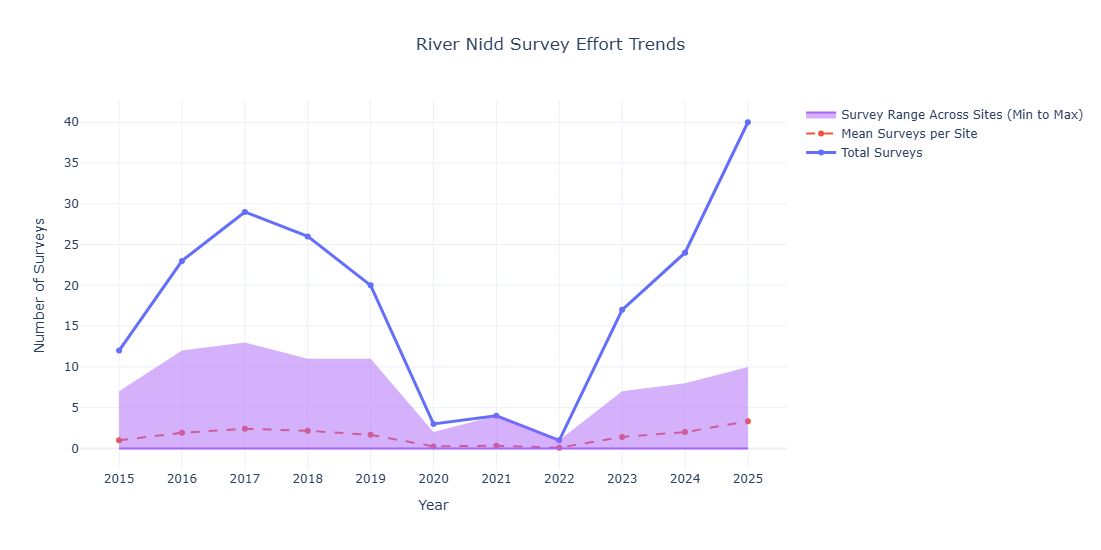

In [32]:
import plotly.graph_objects as go

year_summary = pd.DataFrame({
    "total_surveys": site_year_pivot.sum(),
    "mean_surveys_per_site": site_year_pivot.mean(),
    "max_surveys_at_single_site": site_year_pivot.max(),
    "min_surveys_at_single_site": site_year_pivot.min()
})

years = year_summary.index.astype(int)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=years, y=year_summary["total_surveys"],
    mode="lines+markers", name="Total Surveys",
    line=dict(width=3),
    hovertemplate="Year: %{x}<br>Total Surveys: %{y}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=years, y=year_summary["mean_surveys_per_site"],
    mode="lines+markers", name="Mean Surveys per Site",
    line=dict(dash="dash"),
    hovertemplate="Year: %{x}<br>Mean Surveys per Site: %{y:.2f}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=years, y=year_summary["max_surveys_at_single_site"],
    mode="lines", line=dict(width=0), showlegend=False,
    hovertemplate="Year: %{x}<br>Max Surveys at a Site: %{y}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=years, y=year_summary["min_surveys_at_single_site"],
    mode="lines", fill="tonexty",
    name="Survey Range Across Sites (Min to Max)",
    hovertemplate="Year: %{x}<br>Min Surveys at a Site: %{y}<extra></extra>"
))

fig.update_layout(
    title=dict(text="River Nidd Survey Effort Trends", x=0.5),
    xaxis=dict(title="Year", tickmode="linear", dtick=1),
    yaxis=dict(title="Number of Surveys", dtick=5),
    legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"),
    margin=dict(r=180),
    template="plotly_white", height=550, width=950
)

fig.show()

#### 2.1.1 Site x Year Survey Frequency Table Over Time for River Nidd Sites

Understanding how survey activity varies over time is essential for assessing monitoring consistency. 
This subsection focuses specifically on River Nidd records from the cleaned dataset.

The analysis includes the following steps:

- **Filter the dataset** to include only River Nidd surveys.  
- **Extract the survey year** from the cleaned `recorded_date` field.  
- **Count the number of surveys** per site per year.  
- **Construct a complete Site × Year table** that includes every year between the minimum and maximum survey year.  
- **Fill missing site-year combinations with zero** to explicitly represent years with no surveys (e.g., 2013 and 2020).  

By including years with zero surveys, the resulting table allows a clear comparison of survey effort across sites and over time. 
This helps to identify gaps, inconsistencies, or uneven monitoring coverage, which is crucial for interpreting biodiversity trends accurately.

In [35]:
# 2.1.1 Survey Frequency Over Time for River Nidd Sites
required_cols = ["river", "site", "recorded_date"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"4.1.1 Missing required columns: {missing_cols}")

df_nidd = df[
    df["river"].astype(str).str.strip().str.lower().str.contains("nidd")
].copy()
df_nidd = df_nidd.dropna(subset=["recorded_date"])

if df_nidd.empty:
    raise ValueError("No valid River Nidd records remain after filtering.")

df_nidd["year"] = df_nidd["recorded_date"].dt.year

all_years = list(range(df_nidd["year"].min(), df_nidd["year"].max() + 1))
all_sites = sorted(df_nidd["site"].astype(str).unique())

counts = df_nidd.groupby(["site", "year"]).size().rename("survey_count")
full_index = pd.MultiIndex.from_product([all_sites, all_years], names=["site", "year"])
site_year_table = counts.reindex(full_index, fill_value=0).reset_index()

site_year_pivot = site_year_table.pivot(index="site", columns="year", values="survey_count")
site_year_pivot["Total Surveys"] = site_year_pivot.sum(axis=1)
site_year_pivot = site_year_pivot.sort_values("Total Surveys", ascending=False)
site_year_pivot = site_year_pivot.drop(columns="Total Surveys")
site_year_pivot.index.name = "Survey Site"
site_year_pivot.columns.name = "Year"

display_df = site_year_pivot.replace(0, "")  # replace zeros with blanks

def style_blanks(val):
    if val == "":
        return "background-color: lightgrey;"  # grey blank cells
    return ""  # leave other cells

styled_table = (
    display_df.style
    .map(style_blanks)
    .set_table_styles([{"selector": "td, th", "props": [("border", "1px solid black")]}])
    .set_caption(
        "<b style='font-size:20px;'>River Nidd Survey Counts by Site and Year</b>"
    )
)

display(styled_table)

Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Survey Site,,,,,,,,,,,
Above Killinghall,7,12,13,11,11,1,,1,7,2,
Hampsthwaite,5,11,12,8,6,2,4,,3,4,5
Killinghall Bridge,,,,5,3,,,,,4,10
Pateley STW DS,,,,,,,,,3,8,7
Duffers,,,,,,,,,,3,7
Knaresborough Lido,,,,,,,,,,,7
Lands Lane,,,,,,,,,,2,4
Low Laithe,,,3,2,,,,,,,
Wath STW US,,,,,,,,,2,1,


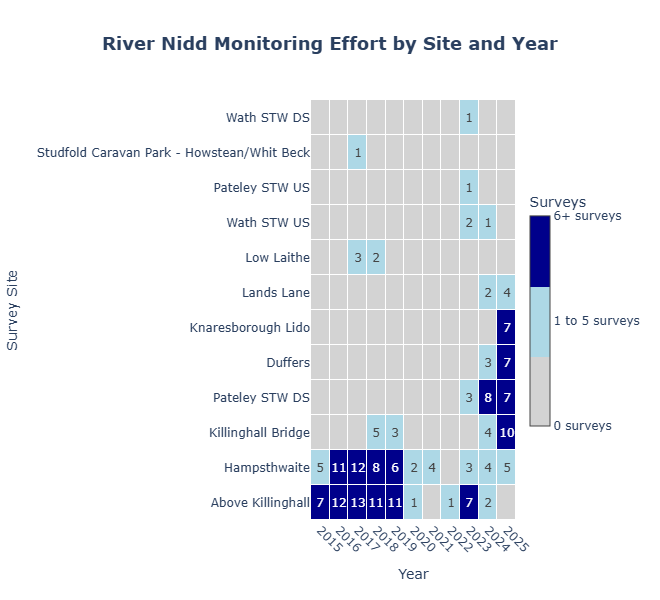

In [74]:
import plotly.graph_objects as go
import numpy as np

TARGET = 6

# Rank sites by total surveys so most active on top
site_order = site_year_pivot.sum(axis=1).sort_values(ascending=False).index
heatmap_values = site_year_pivot.loc[site_order].replace(0, np.nan)

# Discrete color mapping: NaN = grey, 1-5 = light blue, 6+ = dark blue
def discrete_color(val):
    if np.isnan(val):
        return 0  # Grey
    elif val < TARGET:
        return 1  # Light blue
    else:
        return 2  # Dark blue

# Apply column-wise using .map to avoid applymap warning
z_discrete = heatmap_values.apply(lambda col: col.map(discrete_color))

# Prepare text labels: only show numbers for non-NaN
def cell_text(val):
    return str(int(val)) if not np.isnan(val) else ""

text_values = heatmap_values.apply(lambda col: col.map(cell_text))

# Discrete color scale
colors = ["lightgrey", "lightblue", "darkblue"]
colorscale = [
    [0.00, colors[0]], [0.33, colors[0]],   # 0 → grey
    [0.33, colors[1]], [0.66, colors[1]],   # 1–5 → light blue
    [0.66, colors[2]], [1.00, colors[2]]    # 6+ → dark blue
]

hover_text = heatmap_values.map(
    lambda val: str(int(val)) if not np.isnan(val) else "0"
)

fig = go.Figure(
    go.Heatmap(
        z=z_discrete,
        x=heatmap_values.columns,
        y=heatmap_values.index,
        text=text_values,
        texttemplate="%{text}",
        customdata=hover_text,  # used for hover
        hovertemplate="Survey Site: %{y}<br>Year: %{x}<br>Number of Surveys: %{customdata}<extra></extra>",
        colorscale=colorscale,
        showscale=True,
        zmin=0,
        zmax=2,
        xgap=1,  # thin vertical borders
        ygap=1,  # thin horizontal borders
        colorbar=dict(
            tickvals=[0, 1, 2],
            ticktext=["0 surveys", "1 to 5 surveys", "6+ surveys"],
            title="Surveys",
            lenmode="fraction",
            len=0.6,
            thickness=20,
            outlinewidth=1
        )
    )
)

fig.update_layout(
    height=600,   # increase height
    width=1000,
    title=dict(
        text="<b>River Nidd Monitoring Effort by Site and Year</b>",
        x=0.5,
        font=dict(size=18)
    ),
    xaxis=dict(
        title="Year",
        tickmode="array",
        tickvals=list(heatmap_values.columns),  # show all years
        tickangle=45
    ),
    yaxis_title="Survey Site",
    plot_bgcolor="white"
)

# Remove gridlines
fig.update_xaxes(showgrid=False, zeroline=False)
fig.update_yaxes(showgrid=False, zeroline=False)

fig.show()

#### 2.1.2 Annual Survey Frequency by Site with Target Threshold

To assess whether monitoring effort meets expected standards, annual survey frequency is visualised separately for each River Nidd site. 
The target benchmark is set at six surveys per year, representing the desired monitoring consistency.

The visualisation incorporates the following features:

- **Colour-coded line segments** – Line segments are displayed in green where survey counts meet or exceed the target threshold, and red where counts fall below the target. This highlights periods of adequate and insufficient monitoring effort.
- **Coloured data markers** – Individual yearly survey counts are marked and coloured according to whether they meet the target.
- **Reference target line** – A horizontal dashed line indicates the survey target, providing a clear visual benchmark.
- **Explicit zero-year representation** – Years with no recorded surveys are included as zero values to prevent gaps in the time series.

By separating plots by site, this approach enables detailed within-site comparison of monitoring consistency over time. 
The colour-coded structure provides an immediate visual indication of years where survey effort met expectations and years where monitoring coverage was limited.

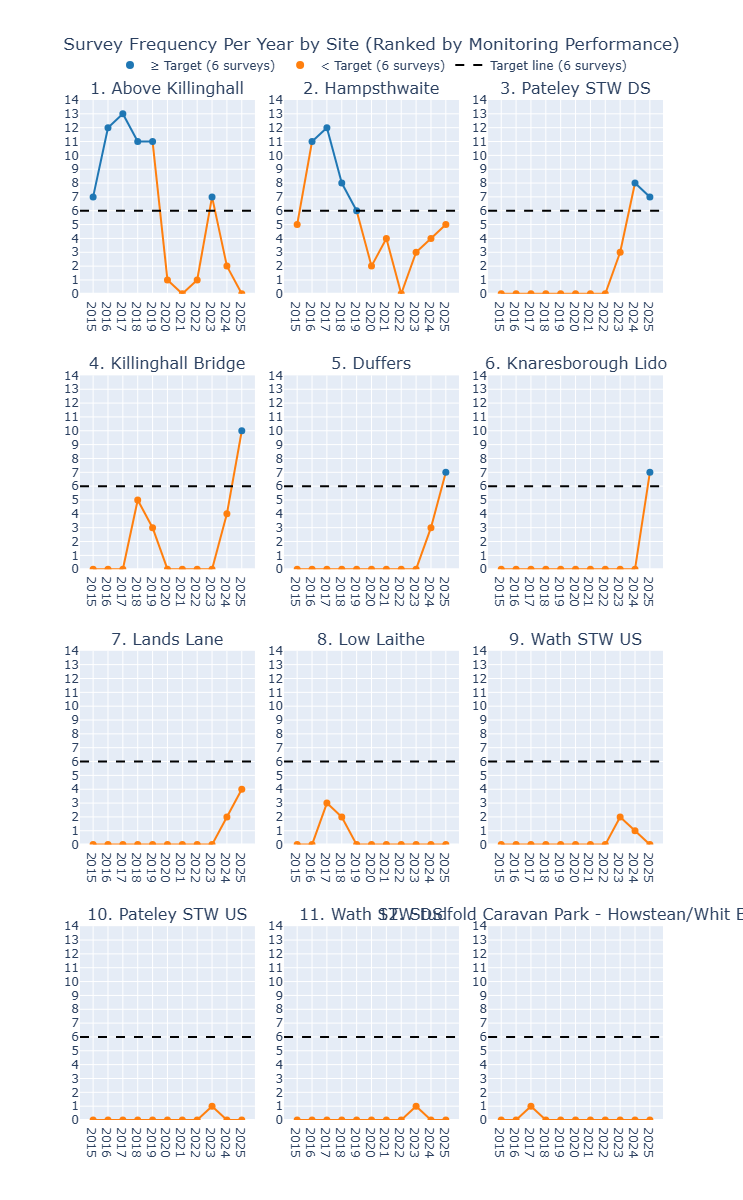

In [64]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math

TARGET = 6

last_year = df_nidd.groupby("site")["year"].max()

site_rank = pd.DataFrame({
    "years_meeting_target": (site_year_pivot >= TARGET).sum(axis=1),
    "total_surveys": site_year_pivot.sum(axis=1),
    "last_survey_year": last_year
}).sort_values(["years_meeting_target","total_surveys","last_survey_year"],
               ascending=[False,False,False])

sites = site_rank.index.tolist()
years = site_year_pivot.columns.tolist()
max_count = site_year_pivot.values.max()

cols = 3
rows = math.ceil(len(sites)/cols)

fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=[f"{i+1}. {s}" for i,s in enumerate(sites)],
    horizontal_spacing=0.05, vertical_spacing=0.08
)

for i,site in enumerate(sites):

    r, c = i//cols+1, i%cols+1
    values = site_year_pivot.loc[site].values

    for j in range(len(years)-1):
        fig.add_trace(go.Scatter(
            x=years[j:j+2], y=values[j:j+2], mode="lines",
            line=dict(color="#1f77b4" if min(values[j],values[j+1])>=TARGET else "#ff7f0e", width=2),
            hovertemplate="Year: %{x}<br>Survey Count: %{y}<extra></extra>",
            showlegend=False
        ), row=r, col=c)

    fig.add_trace(go.Scatter(
        x=years, y=values, mode="markers",
        marker=dict(size=7, color=["#1f77b4" if v>=TARGET else "#ff7f0e" for v in values]),
        hovertemplate="Year: %{x}<br>Survey Count: %{y}<extra></extra>",
        showlegend=False
    ), row=r, col=c)

    fig.add_hline(y=TARGET, line_dash="dash", line_color="black", row=r, col=c)

fig.update_yaxes(range=[0, max_count+1], dtick=1)
fig.update_xaxes(dtick=1)

fig.add_trace(go.Scatter(x=[None],y=[None],mode="markers",marker=dict(size=8,color="#1f77b4"),name="≥ Target (6 surveys)"))
fig.add_trace(go.Scatter(x=[None],y=[None],mode="markers",marker=dict(size=8,color="#ff7f0e"),name="< Target (6 surveys)"))
fig.add_trace(go.Scatter(x=[None],y=[None],mode="lines",line=dict(color="black",dash="dash"),name="Target line (6 surveys)"))

fig.update_layout(
    height=300*rows,
    title=dict(text="Survey Frequency Per Year by Site (Ranked by Monitoring Performance)", x=0.5),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)

fig.show()

### 2.2 Between-Site Variation
How does the data vary between sites? (visually – can we order sites from the top of the catchment down)  

#### 2.2.1 Approach 1 - Catchment Ordering of Monitoring Sites (Google Search)

To enable meaningful spatial comparison between sites, monitoring locations were ordered from upstream to downstream along the River Nidd catchment.

Although Principal Component Analysis (PCA) was explored as a method to derive a dominant spatial gradient from site coordinates, the River Nidd follows a curved, non-linear course. As a result, PCA-based ordering does not perfectly reflect true hydrological flow direction. Therefore, final site ordering was determined using documented upstream and downstream relationships and geographic references.

The River Nidd flows from upland areas near Lofthouse through Pateley Bridge, Hampsthwaite, Killinghall, and into Knaresborough before joining the River Ouse. Based on this hydrological flow, the monitoring sites are ordered as follows:

1. Wath STW US  
2. Wath STW DS  
3. Studfold Caravan Park – Howstean/Whit Beck  
4. Low Laithe  
5. Pateley STW US  
6. Pateley STW DS  
7. Lands Lane  
8. Hampsthwaite  
9. Duffers  
10. Above Killinghall  
11. Killinghall Bridge  
12. Knaresborough Lido  

This upstream-to-downstream structure provides the framework for all subsequent between-site visualisations.

#### 2.2.1 Approach 2 - Catchment Ordering of Monitoring Sites (Using coordinates)

In [9]:
import folium
from IPython.display import display

# Extract River Nidd records with coordinates
site_coords = df[
    df["river"].astype(str).str.lower().str.contains("nidd", na=False)
][["site", "location_latitude", "location_longitude"]].dropna()

# Keep only sites with a single unique coordinate
site_unique_coords = site_coords.groupby("site").filter(
    lambda x: x["location_latitude"].nunique() == 1 and x["location_longitude"].nunique() == 1
).drop_duplicates(subset=["site"])


m = folium.Map(location=[54.0, -1.5], zoom_start=10)

for _, row in site_unique_coords.iterrows():
    folium.Marker(
        location=[row["location_latitude"], row["location_longitude"]],
        popup=row["site"],
        icon=folium.Icon(color="blue", icon="tint")
    ).add_to(m)

display(m)

In [16]:
site_order_by_map = site_unique_coords.sort_values(
    ["location_latitude", "location_longitude"], ascending=[False, True]
)["site"].tolist()
print(site_order_by_map)

['Studfold Caravan Park - Howstean/Whit Beck', 'Wath STW US', 'Wath STW DS', 'Pateley STW US', 'Pateley STW DS', 'Low Laithe', 'Duffers', 'Killinghall Bridge', 'Hampsthwaite', 'Above Killinghall', 'Lands Lane', 'Knaresborough Lido']


#### Coding VS Visual is different

VS Visual observation order: 
site_order_manual =
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Wath STW US",
    "Wath STW DS",
    "Pateley STW US",
    "Pateley STW DS",
    "Low Laithe",
    "Duffers",
    "Hampsthwaite",
    "Above Killinghall",
    "Killinghall Bridge",
    "Lands Lane",
    "Knaresborough Lido"

#### 2.2.2 Between-Site Riverfly Abundance (Adjusted for Survey Frequency)

To compare riverfly abundance across monitoring sites fairly, both spatial and temporal variation in survey effort must be considered. Some sites were heavily sampled across multiple years, while others were only sampled in a few years. Using raw totals would bias results toward heavily sampled sites.

To control for uneven sampling:

1. **Site-Year Mean**: Abundance values are averaged within each site for each year, giving equal weight to every surveyed year.  
2. **Site-Level Mean**: The site-year means are then averaged across all available years, producing a single mean abundance per site.  

This approach standardises for both **survey frequency** and **temporal coverage**, providing a robust comparison of relative abundance between sites.

The results are visualised in a bar chart with sites ordered **upstream to downstream** along the River Nidd. Additionally, survey effort per site is displayed to highlight reliability of the estimates.

How to read this graph:
- Blue bar = average ARMI score at each site
- Black dots = ARMI score for each year
- “Total surveys” shows how much data supports each average
- Sites are ordered from upstream (left) to downstream (right)

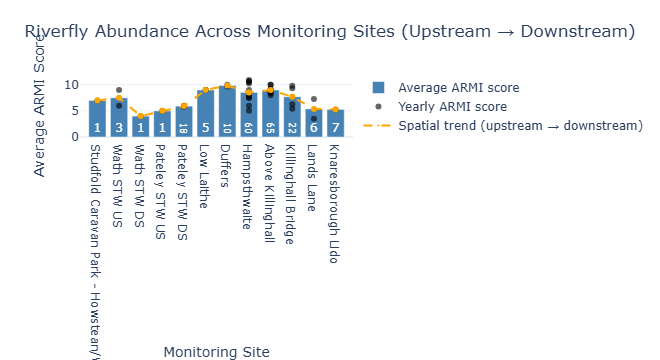

In [68]:
import pandas as pd
import plotly.graph_objects as go

# Make a copy of River Nidd data
nidd = df_nidd.copy()
nidd['year'] = nidd['recorded_date'].dt.year

# 1. Compute site-year mean
site_year_mean = (
    nidd.groupby(['site', 'year'])['armi_total']
    .mean()
    .reset_index(name='mean_armi')
)

# 2. Compute site-level mean across years
site_mean = (
    site_year_mean.groupby('site')['mean_armi']
    .mean()
    .reset_index(name='site_mean_armi')
)

# 3. Compute survey effort per site
site_effort = (
    nidd.groupby('site')['armi_total']
    .count()
    .reset_index(name='total_surveys')
)

# 4. Merge into summary table
site_summary = pd.merge(site_mean, site_effort, on='site')

# 5. Upstream → downstream order (full site names)
hydro_order_full = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Wath STW US",
    "Wath STW DS",
    "Pateley STW US",
    "Pateley STW DS",
    "Low Laithe",
    "Duffers",
    "Hampsthwaite",
    "Above Killinghall",
    "Killinghall Bridge",
    "Lands Lane",
    "Knaresborough Lido"
]

# Set categorical ordering
site_summary['site'] = pd.Categorical(site_summary['site'], categories=hydro_order_full, ordered=True)
site_year_mean['site'] = pd.Categorical(site_year_mean['site'], categories=hydro_order_full, ordered=True)

# Sort for plotting
site_summary = site_summary.sort_values('site')
site_year_mean = site_year_mean.sort_values('site')

# 6. Plot
fig = go.Figure()

# Bars: site-level mean ARMI
fig.add_trace(go.Bar(
    x=site_summary['site'],
    y=site_summary['site_mean_armi'],
    marker_color='steelblue',
    name='Average ARMI score',
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Average ARMI score: %{y:.1f}<br>"
        "Total surveys: %{customdata}<extra></extra>"
    ),
    customdata=site_summary['total_surveys'],
    text=site_summary['total_surveys'],
    textposition='inside',
    insidetextanchor='start',
    textfont=dict(color='white', size=12)
))

# Dots: yearly ARMI scores
fig.add_trace(go.Scatter(
    x=site_year_mean['site'],
    y=site_year_mean['mean_armi'],
    mode='markers',
    marker=dict(color='black', size=6, opacity=0.6),
    name='Yearly ARMI score',
    customdata=site_year_mean['year'],
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Year: %{customdata}<br>"
        "ARMI score: %{y:.1f}<extra></extra>"
    )
))

# Orange dashed line to show upstream → downstream trend
fig.add_trace(go.Scatter(
    x=site_summary['site'],
    y=site_summary['site_mean_armi'],
    mode='lines+markers',
    line=dict(color='orange', dash='dash', width=2),
    marker=dict(size=0),
    name='Spatial trend (upstream → downstream)',
    hoverinfo='skip'
))

# Layout
fig.update_layout(
    title=dict(text="Riverfly Abundance Across Monitoring Sites (Upstream → Downstream)", x=0.5),
    xaxis_title='Monitoring Site',
    yaxis_title='Average ARMI Score',
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.02
    ),
    margin=dict(b=120, r=150)
)

# Ensure the x-axis uses the categorical order
fig.update_xaxes(categoryorder='array', categoryarray=hydro_order_full)

fig.show()

#### 2.2.3 Species Composition and Biodiversity Across Sites

Beyond total counts, it is important to examine how species composition varies between sites.

This analysis explores differences in individual riverfly species abundance across monitoring locations. Comparing species-level patterns allows for:

- Identification of sites supporting greater species diversity  
- Detection of species that are more prevalent upstream or downstream  
- Recognition of spatial shifts in pollution-sensitive taxa  

Examining biodiversity at the species level provides deeper ecological insight than total counts alone and strengthens interpretation of spatial trends across the River Nidd catchment.

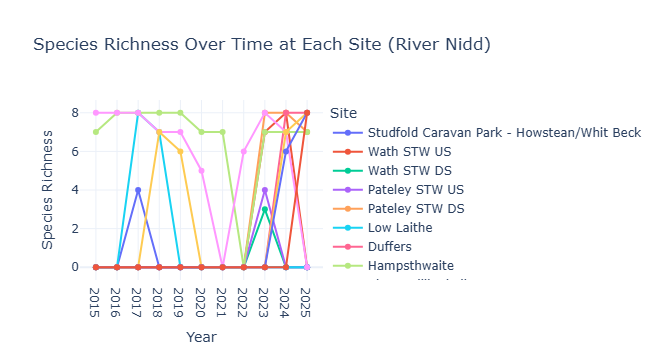

In [69]:
import pandas as pd
import numpy as np
import plotly.express as px

# --- Preprocessing ---
species_cols = [
    'count_cased_caddis', 'count_caseless_caddis',
    'count_mayfly_(ephemeridae)', 'count_blue-winged_olive_(ephemerellidae)',
    'count_flat-bodied_stone_clinger_(heptageniidae)',
    'count_olives_(baetidae)', 'count_stoneflies_(plecoptera)',
    'count_freshwater_shrimp'
]

df_nidd['year'] = df_nidd['recorded_date'].dt.year

# Compute integer species richness per site per year
species_sum = df_nidd.groupby(['site','year'])[species_cols].sum()
species_richness_per_year = (species_sum > 0).sum(axis=1).reset_index(name='species_richness')

# Full site × year grid to include missing years
sites = df_nidd['site'].unique()
years = np.arange(df_nidd['year'].min(), df_nidd['year'].max()+1)
full_grid = pd.MultiIndex.from_product([sites, years], names=['site','year']).to_frame(index=False)

species_richness_per_year = full_grid.merge(
    species_richness_per_year, on=['site','year'], how='left'
)
species_richness_per_year['species_richness'] = species_richness_per_year['species_richness'].fillna(0).astype(int)

# Upstream → downstream order
hydro_order_full = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Wath STW US",
    "Wath STW DS",
    "Pateley STW US",
    "Pateley STW DS",
    "Low Laithe",
    "Duffers",
    "Hampsthwaite",
    "Above Killinghall",
    "Killinghall Bridge",
    "Lands Lane",
    "Knaresborough Lido"
]

species_richness_per_year['site'] = pd.Categorical(
    species_richness_per_year['site'], categories=hydro_order_full, ordered=True
)
species_richness_per_year = species_richness_per_year.sort_values(['site','year'])

# --- Line plot ---
fig_line = px.line(
    species_richness_per_year,
    x='year',
    y='species_richness',
    color='site',
    markers=True,
    title='Species Richness Over Time at Each Site (River Nidd)',
    labels={'year':'Year','species_richness':'Species Richness','site':'Site'}
)

fig_line.update_layout(
    template='plotly_white',
    xaxis=dict(tickmode='linear', dtick=1)
)

fig_line.show()

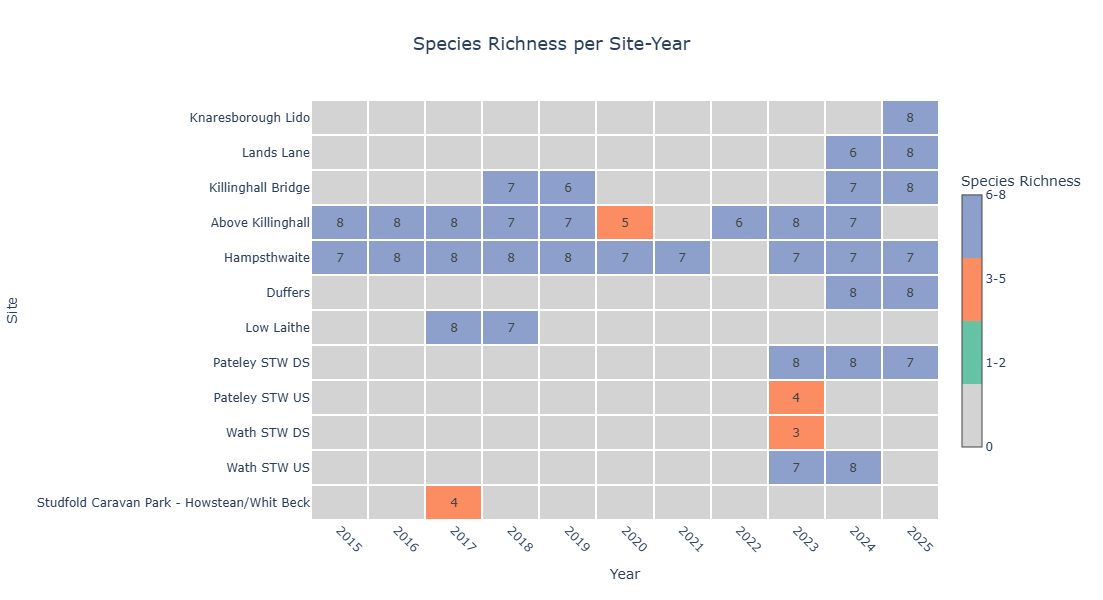

In [76]:
species_cols = [
    'count_cased_caddis', 'count_caseless_caddis',
    'count_mayfly_(ephemeridae)', 'count_blue-winged_olive_(ephemerellidae)',
    'count_flat-bodied_stone_clinger_(heptageniidae)',
    'count_olives_(baetidae)', 'count_stoneflies_(plecoptera)',
    'count_freshwater_shrimp'
]

df_nidd['year'] = df_nidd['recorded_date'].dt.year

species_sum = df_nidd.groupby(['site','year'])[species_cols].sum()
species_richness_per_year = (species_sum > 0).sum(axis=1).reset_index(name='species_richness')

# Full site × year grid
sites = df_nidd['site'].unique()
years = np.arange(df_nidd['year'].min(), df_nidd['year'].max()+1)
full_grid = pd.MultiIndex.from_product([sites, years], names=['site','year']).to_frame(index=False)

species_richness_per_year = full_grid.merge(
    species_richness_per_year, on=['site','year'], how='left'
)
species_richness_per_year['species_richness'] = species_richness_per_year['species_richness'].fillna(0).astype(int)

# Upstream → downstream order
hydro_order_full = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Wath STW US",
    "Wath STW DS",
    "Pateley STW US",
    "Pateley STW DS",
    "Low Laithe",
    "Duffers",
    "Hampsthwaite",
    "Above Killinghall",
    "Killinghall Bridge",
    "Lands Lane",
    "Knaresborough Lido"
]

species_richness_per_year['site'] = pd.Categorical(
    species_richness_per_year['site'], categories=hydro_order_full, ordered=True
)
species_richness_per_year = species_richness_per_year.sort_values(['site','year'])

# --- Bin species richness into ranges ---
def richness_bin(val):
    if val == 0:
        return 0  # Grey
    elif 1 <= val <= 2:
        return 1
    elif 3 <= val <= 5:
        return 2
    else:
        return 3

z_discrete = species_richness_per_year.pivot(index='site', columns='year', values='species_richness')
z_discrete = z_discrete.map(richness_bin)

# Labels: hide zeros
text_values = species_richness_per_year.pivot(index='site', columns='year', values='species_richness')
text_values = text_values.map(lambda x: str(x) if x > 0 else "")

# Colorblind-friendly palette
colors = ["#D3D3D3", "#66C2A5", "#FC8D62", "#8DA0CB"]  # grey, green, orange, blue
colorscale = [
    [0.0, colors[0]], [0.25, colors[0]],
    [0.25, colors[1]], [0.5, colors[1]],
    [0.5, colors[2]], [0.75, colors[2]],
    [0.75, colors[3]], [1.0, colors[3]],
]

hover_text = species_richness_per_year.pivot(index='site', columns='year', values='species_richness').map(str)

# --- Plot ---
fig = go.Figure(
    go.Heatmap(
        z=z_discrete,
        x=text_values.columns,
        y=text_values.index,
        text=text_values,
        texttemplate="%{text}",
        customdata=hover_text,
        hovertemplate="Site: %{y}<br>Year: %{x}<br>Species Richness: %{customdata}<extra></extra>",
        colorscale=colorscale,
        showscale=True,
        zmin=0,
        zmax=3,
        xgap=2,
        ygap=2,
        colorbar=dict(
            tickvals=[0,1,2,3],
            ticktext=["0","1-2","3-5","6-8"],
            title="Species Richness",
            lenmode="fraction",
            len=0.7,
            thickness=20,
            outlinewidth=1
        )
    )
)

fig.update_layout(
    height=600,
    width=1000,
    title=dict(text='Species Richness per Site-Year', x=0.5, font=dict(size=18)),
    xaxis=dict(title='Year', tickmode='array', tickvals=list(text_values.columns), tickangle=45),
    yaxis_title='Site',
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=False, zeroline=False)
fig.update_yaxes(showgrid=False, zeroline=False)

fig.show()

### 2.3 Between-site Species Analysis
Are we seeing any significant fluctuations, patterns or variation of the different riverfly species between sites?

#### 2.3.1 Species Abundance Summary Across Sites
This subsection outlines the process used to summarise riverfly species abundance across monitoring sites on the River Nidd. A species × site matrix was generated using the raw count data for the eight standard Riverfly Monitoring Initiative taxa groups. For each site, total counts were aggregated across all available surveys to provide an overall measure of species presence and abundance.

Species richness was calculated for each site as the number of taxa with non‑zero counts. This metric provides a simple indication of how many riverfly groups were recorded at each location. These summaries form the basis for the subsequent between‑site comparisons presented in Section 2.3.2.

In [77]:
# 2.3.1 Species Abundance Summary Across Sites (River Nidd Only)

# 1. Filter to River Nidd
nidd_only = df[df['river'] == 'Nidd'].copy()

# 2. Drop rows with missing site names
nidd_only = nidd_only.dropna(subset=['site'])

# 3. Simplify site names
rename_map = {
    'Studfold Caravan Park - Howstean/Whit Beck': 'Studfold',
    'Pateley STW US': 'Pateley US',
    'Pateley STW DS': 'Pateley DS',
    'Above Killinghall Bridge': 'Above Killinghall',
    'Killinghall Bridge': 'Killinghall'
}
nidd_only['site'] = nidd_only['site'].replace(rename_map)

# 4. Define species columns
species_cols = [
    'count_cased_caddis',
    'count_caseless_caddis',
    'count_mayfly_(ephemeridae)',
    'count_blue-winged_olive_(ephemerellidae)',
    'count_flat-bodied_stone_clinger_(heptageniidae)',
    'count_olives_(baetidae)',
    'count_stoneflies_(plecoptera)',
    'count_freshwater_shrimp'
]

# 5. Build species × site matrix
species_matrix = (
    nidd_only.groupby('site')[species_cols]
    .sum()
    .reset_index()
)

# 6. Calculate richness
species_matrix['species_richness'] = (species_matrix[species_cols] > 0).sum(axis=1)

# 7. Apply upstream → downstream order
hydro_order = [
    'Wath US', 'Wath STW US', 'Wath STW DS', 'Studfold', 'Low Laithe',
    'Pateley US', 'Pateley DS', 'Lands Lane', 'Hampsthwaite',
    'Duffers', 'Above Killinghall', 'Killinghall', 'Knaresborough Lido'
]

species_matrix['site'] = pd.Categorical(species_matrix['site'], categories=hydro_order, ordered=True)
species_matrix = species_matrix.sort_values('site').reset_index(drop=True)

species_matrix

,site,count_cased_caddis,count_caseless_caddis,count_mayfly_(ephemeridae),count_blue-winged_olive_(ephemerellidae),count_flat-bodied_stone_clinger_(heptageniidae),count_olives_(baetidae),count_stoneflies_(plecoptera),count_freshwater_shrimp,species_richness
0,Wath STW US,21.0,10.0,8.0,6.0,3.0,7.0,33.0,10.0,8
1,Wath STW DS,3.0,2.0,0.0,0.0,0.0,0.0,15.0,0.0,3
2,Studfold,8.0,0.0,0.0,0.0,12.0,100.0,3.0,0.0,4
3,Low Laithe,70.0,18.0,6.0,1.0,110.0,207.0,85.0,4.0,8
4,Pateley US,5.0,2.0,0.0,0.0,1.0,0.0,10.0,0.0,4
5,Pateley DS,111.0,46.0,20.0,29.0,42.0,32.0,96.0,2.0,8
6,Lands Lane,20.0,20.0,3.0,84.0,18.0,70.0,42.0,7.0,8
7,Hampsthwaite,1063.0,263.0,205.0,739.0,1287.0,1667.0,1352.0,10.0,8
8,Duffers,28.0,80.0,36.0,47.0,511.0,1357.0,167.0,8.0,8
9,Above Killinghall,508.0,524.0,290.0,385.0,2488.0,4077.0,912.0,12.0,8


#### 2.3.2 Visualising Species Differences Between Sites

This subsection describes the methods used to compare riverfly species composition across monitoring sites along the River Nidd, taking into account differences in survey effort and temporal coverage. To control for variation in survey frequency, raw counts of each taxon were converted to mean counts per survey. For each site 𝑠 and year 𝑦, the mean count of taxon 𝑖 was calculated as:

$$
\mathrm{Mean\ Count}_{s,y,i} =
\frac{\mathrm{Count\ of\ taxon\ } i \text{ at site } s \text{ in year } y}{\text{Number of surveys at site } s \text{ in year } y}
$$

This adjustment ensures that sites with more surveys do not appear artificially more abundant, providing a fair comparison of species presence and dominance across sites and years. To capture both temporal trends and overall site composition:
- Mean counts were calculated for each year individually (2015–2025).
- A “Total” frame was computed by averaging across all surveys at each site over the full time period.
- All site × year × taxon combinations were included, so that taxa absent in some years or sites are represented as zero counts. This preserves the spatial and temporal structure of the dataset.

This approach allows clear visual identification of spatial patterns, species dominance, and between-site variation, forming the foundation for downstream analysis of sensitive vs. tolerant taxa, site clusters, and potential impacts of anthropogenic pressures.ysis.

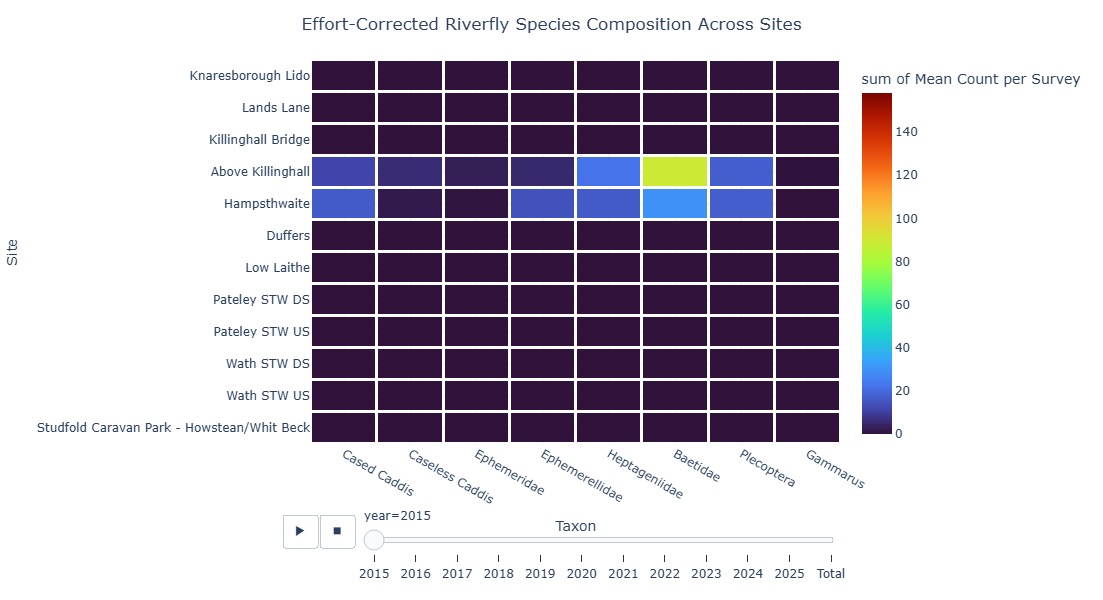

In [82]:
global_min = species_long["Mean Count per Survey"].min()
global_max = species_long["Mean Count per Survey"].max()

# --- Hydrological upstream → downstream order (full names) ---
hydro_order_full = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Wath STW US",
    "Wath STW DS",
    "Pateley STW US",
    "Pateley STW DS",
    "Low Laithe",
    "Duffers",
    "Hampsthwaite",
    "Above Killinghall",
    "Killinghall Bridge",
    "Lands Lane",
    "Knaresborough Lido"
]

# --- Species columns ---
species_cols = [
    'count_cased_caddis', 'count_caseless_caddis',
    'count_mayfly_(ephemeridae)', 'count_blue-winged_olive_(ephemerellidae)',
    'count_flat-bodied_stone_clinger_(heptageniidae)',
    'count_olives_(baetidae)', 'count_stoneflies_(plecoptera)',
    'count_freshwater_shrimp'
]

# --- Add year column ---
df_nidd['year'] = df_nidd['recorded_date'].dt.year

# --- Ensure site is categorical in hydrological order ---
df_nidd['site'] = pd.Categorical(df_nidd['site'], categories=hydro_order_full, ordered=True)

# --- Compute mean counts per survey per site per year ---
species_per_year = (
    df_nidd.groupby(['site', 'year'], observed=False)[species_cols]
    .sum()
    .div(df_nidd.groupby(['site', 'year'], observed=False).size(), axis=0)
    .reset_index()
)

# --- Compute total across all years ---
species_total = (
    df_nidd.groupby('site', observed=False)[species_cols]
    .sum()
    .div(df_nidd.groupby('site', observed=False).size(), axis=0)
    .reset_index()
)
species_total['year'] = 'Total'

# --- Combine per-year and total ---
species_all = pd.concat([species_per_year, species_total], ignore_index=True)

# --- Rename taxa for readability ---
rename_taxa = {
    'count_cased_caddis': 'Cased Caddis',
    'count_caseless_caddis': 'Caseless Caddis',
    'count_mayfly_(ephemeridae)': 'Ephemeridae',
    'count_blue-winged_olive_(ephemerellidae)': 'Ephemerellidae',
    'count_flat-bodied_stone_clinger_(heptageniidae)': 'Heptageniidae',
    'count_olives_(baetidae)': 'Baetidae',
    'count_stoneflies_(plecoptera)': 'Plecoptera',
    'count_freshwater_shrimp': 'Gammarus'
}
species_all = species_all.rename(columns=rename_taxa)
species_cols_readable = list(rename_taxa.values())

# --- Melt to long format ---
species_long = species_all.melt(
    id_vars=['site', 'year'],
    value_vars=species_cols_readable,
    var_name='Taxon',
    value_name='Mean Count per Survey'
)

# --- Create full site × year × taxon grid ---
sites = hydro_order_full
years = [str(y) for y in range(2015, 2026)] + ['Total']
taxa = species_cols_readable

full_grid = pd.MultiIndex.from_product(
    [sites, years, taxa],
    names=['site', 'year', 'Taxon']
).to_frame(index=False)

# --- Merge actual data, fill missing with 0 ---
species_long['year'] = species_long['year'].astype(str)
species_long = pd.merge(
    full_grid, species_long,
    on=['site', 'year', 'Taxon'],
    how='left'
)
species_long['Mean Count per Survey'] = species_long['Mean Count per Survey'].fillna(0)

# --- Set categorical orders for plotting ---
species_long['site'] = pd.Categorical(species_long['site'], categories=hydro_order_full, ordered=True)
species_long['year'] = pd.Categorical(species_long['year'], categories=years, ordered=True)
species_long['Taxon'] = pd.Categorical(species_long['Taxon'], categories=taxa, ordered=True)

fig = px.density_heatmap(
    species_long,
    x='Taxon',
    y='site',
    z='Mean Count per Survey',
    animation_frame='year',
    color_continuous_scale='Turbo',
    range_color=[global_min, global_max],
    text_auto=False,
    labels={'site':'Site', 'Taxon':'Taxon', 'Mean Count per Survey':'Mean Count per Survey'}
)

fig.update_traces(
    xgap=3,
    ygap=3,
    hovertemplate="<b>Site:</b> %{y}<br><b>Taxon:</b> %{x}<br><b>Mean count per survey:</b> %{z:.2f}<extra></extra>"
)

fig.update_layout(
    title=dict(text="Effort-Corrected Riverfly Species Composition Across Sites", x=0.5),
    xaxis_title="Taxon",
    yaxis_title="Site",
    template="plotly_white",
    font=dict(size=12),
    height=50 * len(hydro_order_full),
    margin=dict(b=150)
)

fig.show()

#### (TBC) 2.3.3 Identifying Spatial Patterns and Between‑Site Variation
Objective
Interpret the visual patterns to determine whether species differ meaningfully between sites.

Patterns to look for
- Upstream vs downstream differences
    - Sensitive taxa more common upstream?
    - Tolerant taxa dominating downstream?
- Site clusters
    - Groups of sites with similar species profiles.
    - Sites that stand out as unusual.
- Species restricted to certain areas
    - Species only found above/below sewage treatment works.
    - Species missing from impacted sections.
- Dominance patterns
- Sites dominated by one or two species (low diversity).
- Sites with balanced species assemblages (high diversity).

What to report
Clear, descriptive statements about spatial variation — no statistics required unless you choose to include them.

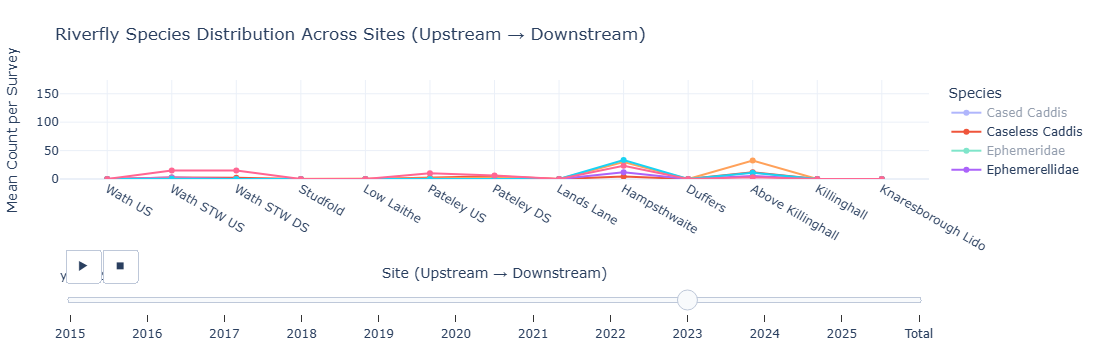

In [13]:
rename_map = {
    'Studfold Caravan Park - Howstean/Whit Beck': 'Studfold',
    'Pateley STW US': 'Pateley US',
    'Pateley STW DS': 'Pateley DS',
    'Above Killinghall Bridge': 'Above Killinghall',
    'Killinghall Bridge': 'Killinghall'
}
df_nidd['site_simple'] = df_nidd['site'].replace(rename_map)

species_cols = [
    'count_cased_caddis','count_caseless_caddis',
    'count_mayfly_(ephemeridae)','count_blue-winged_olive_(ephemerellidae)',
    'count_flat-bodied_stone_clinger_(heptageniidae)',
    'count_olives_(baetidae)','count_stoneflies_(plecoptera)',
    'count_freshwater_shrimp'
]

df_nidd['year'] = df_nidd['recorded_date'].dt.year

hydro_order = [
    'Wath US','Wath STW US','Wath STW DS','Studfold','Low Laithe',
    'Pateley US','Pateley DS','Lands Lane','Hampsthwaite',
    'Duffers','Above Killinghall','Killinghall','Knaresborough Lido'
]

all_years = list(range(2015,2026))

species_year = (
    df_nidd.groupby(['site_simple','year'])[species_cols]
    .sum()
    .div(df_nidd.groupby(['site_simple','year']).size(),axis=0)
    .reset_index()
)

species_long = species_year.melt(
    id_vars=['site_simple','year'],
    value_vars=species_cols,
    var_name='species',
    value_name='mean_count'
)

full_grid = pd.MultiIndex.from_product(
    [hydro_order,all_years,species_cols],
    names=['site_simple','year','species']
).to_frame(index=False)

species_long = full_grid.merge(
    species_long,
    on=['site_simple','year','species'],
    how='left'
)

species_long['mean_count'] = species_long['mean_count'].fillna(0)

species_total = (
    df_nidd.groupby('site_simple')[species_cols]
    .sum()
    .div(df_nidd.groupby('site_simple').size(),axis=0)
    .reset_index()
)

species_total['year'] = 'Total'

species_total_long = species_total.melt(
    id_vars=['site_simple','year'],
    value_vars=species_cols,
    var_name='species',
    value_name='mean_count'
)

species_long = pd.concat(
    [species_long, species_total_long],
    ignore_index=True
)


rename_taxa = {
    'count_cased_caddis':'Cased Caddis',
    'count_caseless_caddis':'Caseless Caddis',
    'count_mayfly_(ephemeridae)':'Ephemeridae',
    'count_blue-winged_olive_(ephemerellidae)':'Ephemerellidae',
    'count_flat-bodied_stone_clinger_(heptageniidae)':'Heptageniidae',
    'count_olives_(baetidae)':'Baetidae',
    'count_stoneflies_(plecoptera)':'Plecoptera',
    'count_freshwater_shrimp':'Gammarus'
}

species_long['species'] = species_long['species'].replace(rename_taxa)

year_order = [str(y) for y in range(2015,2026)] + ['Total']

species_long['year'] = species_long['year'].astype(str)
species_long['year'] = pd.Categorical(species_long['year'],categories=year_order,ordered=True)

species_long['site_simple'] = pd.Categorical(
    species_long['site_simple'],
    categories=hydro_order,
    ordered=True
)

y_max = species_long['mean_count'].max() * 1.1

fig = px.line(
    species_long,
    x='site_simple',
    y='mean_count',
    color='species',
    line_group='species',
    markers=True,
    animation_frame='year',
    labels={
        'site_simple':'Site',
        'mean_count':'Mean Count per Survey',
        'species':'Species'
    },
    title='Riverfly Species Distribution Across Sites (Upstream → Downstream)'
)

fig.update_layout(

    xaxis=dict(
        title="Site (Upstream → Downstream)",
        categoryorder='array',
        categoryarray=hydro_order
    ),

    yaxis=dict(
        title="Mean Count per Survey",
        range=[0,y_max]
    ),

    template='plotly_white',
    height=600,

    margin=dict(
        l=60,
        r=30,
        t=80,
        b=130   
    )
)

fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1400
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 600

fig.update_layout(
    sliders=[dict(
        y=-0.25,
        x=0,
        len=1.0
    )]
)

fig.show()

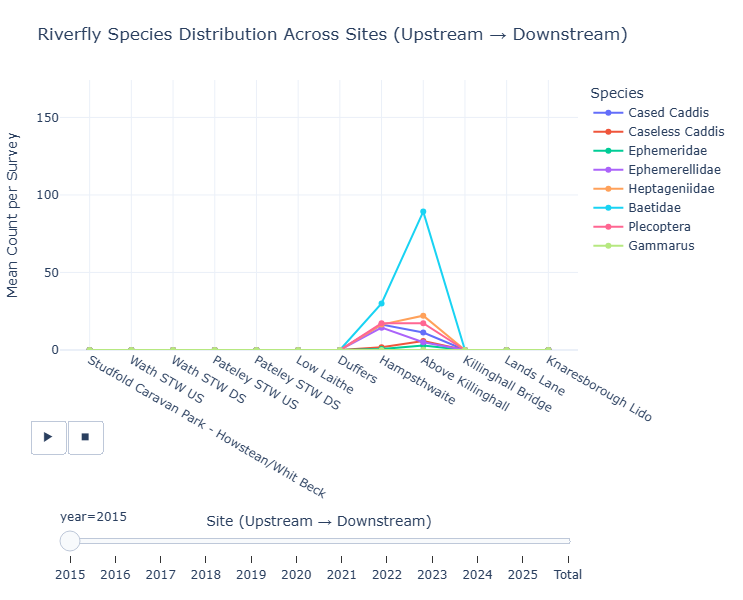

In [85]:
species_cols = [
    'count_cased_caddis','count_caseless_caddis',
    'count_mayfly_(ephemeridae)','count_blue-winged_olive_(ephemerellidae)',
    'count_flat-bodied_stone_clinger_(heptageniidae)',
    'count_olives_(baetidae)','count_stoneflies_(plecoptera)',
    'count_freshwater_shrimp'
]

df_nidd['year'] = df_nidd['recorded_date'].dt.year

hydro_order_full = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Wath STW US",
    "Wath STW DS",
    "Pateley STW US",
    "Pateley STW DS",
    "Low Laithe",
    "Duffers",
    "Hampsthwaite",
    "Above Killinghall",
    "Killinghall Bridge",
    "Lands Lane",
    "Knaresborough Lido"
]

all_years = list(range(2015, 2026))

# --- Mean per site-year ---
species_year = (
    df_nidd.groupby(['site','year'], observed=True)[species_cols]
    .sum()
    .div(df_nidd.groupby(['site','year'], observed=True).size(), axis=0)
    .reset_index()
)

# --- Long format ---
species_long = species_year.melt(
    id_vars=['site','year'],
    value_vars=species_cols,
    var_name='species',
    value_name='mean_count'
)

# --- Full grid (IMPORTANT: use full names) ---
full_grid = pd.MultiIndex.from_product(
    [hydro_order_full, all_years, species_cols],
    names=['site','year','species']
).to_frame(index=False)

species_long = full_grid.merge(
    species_long,
    on=['site','year','species'],
    how='left'
)

species_long['mean_count'] = species_long['mean_count'].fillna(0)

# --- Site-level total ---
species_total = (
    df_nidd.groupby('site', observed=True)[species_cols]
    .sum()
    .div(df_nidd.groupby('site', observed=True).size(), axis=0)
    .reset_index()
)

species_total['year'] = 'Total'

species_total_long = species_total.melt(
    id_vars=['site','year'],
    value_vars=species_cols,
    var_name='species',
    value_name='mean_count'
)

# --- Combine ---
species_long = pd.concat(
    [species_long, species_total_long],
    ignore_index=True
)

# --- Rename taxa ---
rename_taxa = {
    'count_cased_caddis':'Cased Caddis',
    'count_caseless_caddis':'Caseless Caddis',
    'count_mayfly_(ephemeridae)':'Ephemeridae',
    'count_blue-winged_olive_(ephemerellidae)':'Ephemerellidae',
    'count_flat-bodied_stone_clinger_(heptageniidae)':'Heptageniidae',
    'count_olives_(baetidae)':'Baetidae',
    'count_stoneflies_(plecoptera)':'Plecoptera',
    'count_freshwater_shrimp':'Gammarus'
}

species_long['species'] = species_long['species'].replace(rename_taxa)

# --- Year ordering ---
year_order = [str(y) for y in range(2015, 2026)] + ['Total']

species_long['year'] = species_long['year'].astype(str)
species_long['year'] = pd.Categorical(
    species_long['year'],
    categories=year_order,
    ordered=True
)

# --- Site ordering (CRITICAL FIX) ---
species_long['site'] = pd.Categorical(
    species_long['site'],
    categories=hydro_order_full,
    ordered=True
)

species_long = species_long.sort_values(['site','year'])

# --- Y-axis max ---
y_max = species_long['mean_count'].max() * 1.1

# --- Plot ---
fig = px.line(
    species_long,
    x='site',
    y='mean_count',
    color='species',
    line_group='species',
    markers=True,
    animation_frame='year',
    labels={
        'site':'Site',
        'mean_count':'Mean Count per Survey',
        'species':'Species'
    },
    title='Riverfly Species Distribution Across Sites (Upstream → Downstream)'
)

fig.update_layout(
    xaxis=dict(
        title="Site (Upstream → Downstream)",
        categoryorder='array',
        categoryarray=hydro_order_full
    ),
    yaxis=dict(
        title="Mean Count per Survey",
        range=[0, y_max]
    ),
    template='plotly_white',
    height=600,
    margin=dict(l=60, r=30, t=80, b=180)
)

# --- Animation speed ---
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1400
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 600

# --- Slider position ---
fig.update_layout(
    sliders=[dict(
        y=-0.35,
        x=0,
        len=1.0
    )]
)

fig.show()

### 2.4 Within‑Site Species Analysis
Within site species analysis: Are we seeing any significant fluctuations, patterns or variation of the different riverfly species at each site? 

#### 2.4.1 Within‑Site Temporal Variation (Method)

This subsection examines how riverfly species composition changes over time within each monitoring site. To retain temporal structure, raw species counts were aggregated by site and year. For each site–year combination, relative abundances were calculated to account for differences in total counts between years. The relative abundance of taxon \(i\) at site \(s\) in year \(t\) was computed as:

$$
RA_{s,i,t} =
\frac{\mathrm{Count\ of\ taxon}\ i}{\sum_{j=1}^{8} \mathrm{Count\ of\ taxon}\ j}
$$

These effort‑corrected values were visualised using faceted line plots, with time on the x‑axis and the relative abundance of each taxon on the y‑axis. One panel was produced per site to highlight within‑site fluctuations, patterns, and shifts in species composition across the monitoring period.


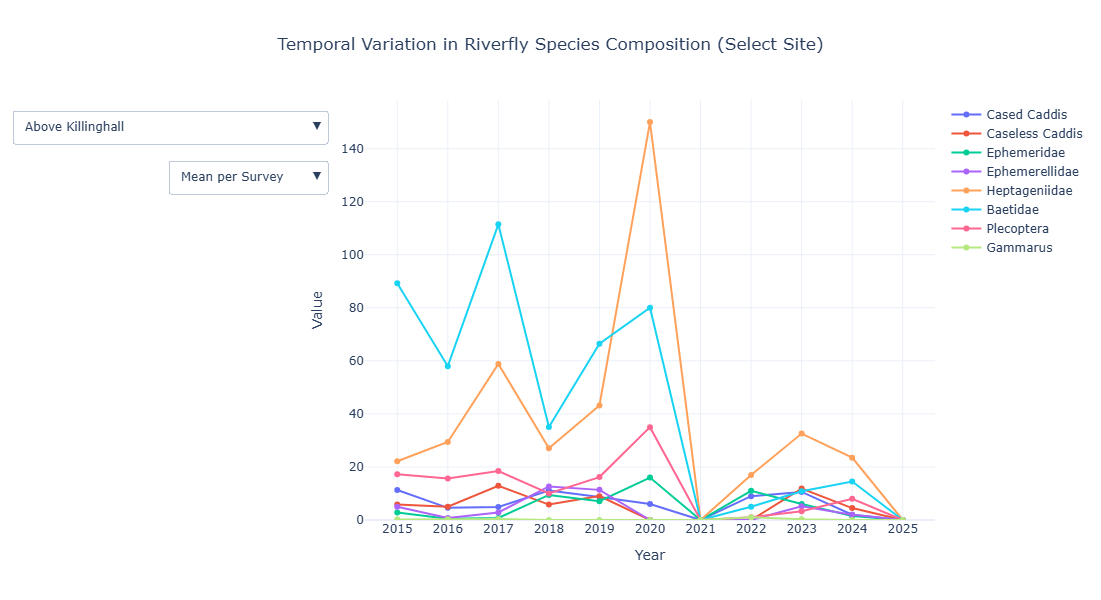

In [86]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --- Filter River Nidd and clean data ---
nidd_only = df[df['river'].str.lower() == 'nidd'].copy()
nidd_only = nidd_only.dropna(subset=['site','recorded_date'])
nidd_only['year'] = pd.to_datetime(nidd_only['recorded_date']).dt.year

# --- Compute mean count per survey per site × year ---
site_year_sum = nidd_only.groupby(['site','year'])[species_cols].sum().reset_index()
site_year_count = nidd_only.groupby(['site','year']).size().reset_index(name='n_surveys')

site_year = pd.merge(site_year_sum, site_year_count, on=['site','year'])
for col in species_cols:
    site_year[col] = site_year[col] / site_year['n_surveys']

# --- Melt to long format ---
plot_long = site_year.melt(
    id_vars=['site','year'],
    value_vars=species_cols,
    var_name='taxon',
    value_name='mean_per_survey'
)

# --- Rename taxa for readability ---
plot_long['taxon'] = plot_long['taxon'].replace(rename_taxa)

# --- Optionally compute relative abundance per row (sum to 1 per year) ---
plot_long['relative_abundance'] = plot_long.groupby(['site','year'])['mean_per_survey'].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 0
)

# --- Complete site × year × taxon grid to fill missing years ---
all_sites = plot_long['site'].unique()
all_taxa = plot_long['taxon'].unique()
all_years = np.arange(plot_long['year'].min(), plot_long['year'].max()+1)

full_index = pd.MultiIndex.from_product(
    [all_sites, all_years, all_taxa],
    names=['site','year','taxon']
).to_frame(index=False)

plot_long_full = pd.merge(
    full_index,
    plot_long,
    on=['site','year','taxon'],
    how='left'
)

plot_long_full['mean_per_survey'] = plot_long_full['mean_per_survey'].fillna(0)
plot_long_full['relative_abundance'] = plot_long_full['relative_abundance'].fillna(0)

# --- Max values for standardized y-axis ---
y_max_abs = plot_long_full['mean_per_survey'].max()
y_max_rel = plot_long_full['relative_abundance'].max()

# --- Build figure: one trace per site × taxon ---
fig = go.Figure()

for site in all_sites:
    for taxon in all_taxa:
        df_trace = plot_long_full[(plot_long_full['site']==site) & (plot_long_full['taxon']==taxon)]
        fig.add_trace(go.Scatter(
            x=df_trace['year'],
            y=df_trace['mean_per_survey'],  # default: mean per survey
            mode='lines+markers',
            name=taxon,
            visible=(site==all_sites[0]),
            hovertemplate=(
                "<b>Year:</b> %{x}<br>"
                "<b>Taxon:</b> %{text}<br>"
                "<b>Mean per Survey:</b> %{y:.2f}<extra></extra>"
            ),
            text=[taxon]*len(df_trace),
            customdata=df_trace['relative_abundance']  # store relative abundance for toggle
        ))

# --- Dropdown per site ---
buttons_sites = []
n_taxa = len(all_taxa)
for i, site in enumerate(all_sites):
    visible = [False]*(len(all_sites)*n_taxa)
    start_idx = i*n_taxa
    visible[start_idx:start_idx+n_taxa] = [True]*n_taxa
    buttons_sites.append(dict(
        label=site,
        method="update",
        args=[{"visible": visible},
              {"title": f"Riverfly Species Composition at {site}"}]
    ))

# --- Toggle for absolute vs relative ---
buttons_mode = [
    dict(
        label="Mean per Survey",
        method="update",
        args=[{"y": [trace.y for trace in fig.data]}, 
              {"yaxis": {"range": [0, y_max_abs]}}]
    ),
    dict(
        label="Relative Abundance",
        method="update",
        args=[{"y": [trace.customdata for trace in fig.data]},
              {"yaxis": {"range": [0, y_max_rel]}}]
    )
]

# --- Update layout ---
fig.update_layout(
    title=dict(text="Temporal Variation in Riverfly Species Composition (Select Site)", x=0.5),
    updatemenus=[
        dict(
            buttons=buttons_sites,
            direction="down",
            xanchor="right",
            showactive=True,
            pad={"r":10,"t":10}
        ),
        dict(
            buttons=buttons_mode,
            direction="down",
            xanchor="right", y=0.88, yanchor="top",
            showactive=True,
            pad={"r":10,"t":10}
        )
    ],
    xaxis_title="Year",
    yaxis_title="Value",
    xaxis=dict(tickmode='array', tickvals=list(all_years)),
    yaxis=dict(range=[0, y_max_abs]),
    template="plotly_white",
    height=600,
)

fig.show()

# BACKUP CODE FRAGMENT

## QUESTION 1 HEATMAP SURVEY FREQUENCY VERSION 1

Year                                        2015  2016  2017  2018  2019  \
Survey Site                                                                
Above Killinghall                              7    12    13    11    11   
Hampsthwaite                                   5    11    12     8     6   
Killinghall Bridge                             0     0     0     5     3   
Pateley STW DS                                 0     0     0     0     0   
Duffers                                        0     0     0     0     0   
Knaresborough Lido                             0     0     0     0     0   
Lands Lane                                     0     0     0     0     0   
Low Laithe                                     0     0     3     2     0   
Wath STW US                                    0     0     0     0     0   
Pateley STW US                                 0     0     0     0     0   
Studfold Caravan Park - Howstean/Whit Beck     0     0     1     0     0   
Wath STW DS 

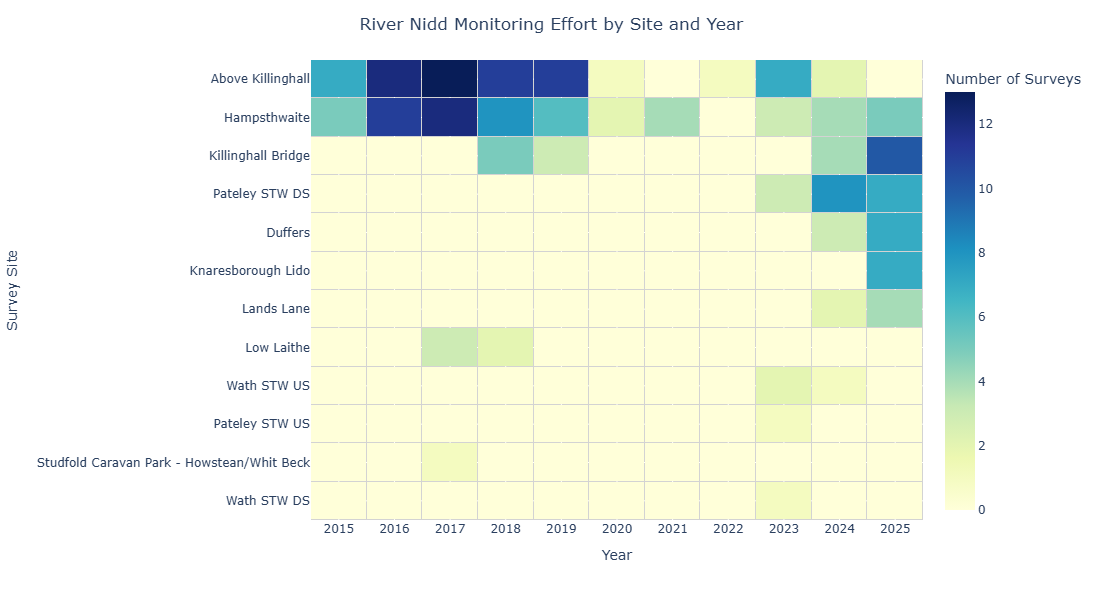

In [33]:
import plotly.express as px

all_years = list(range(site_year_pivot.columns.min(), site_year_pivot.columns.max()+1))
site_year_pivot = site_year_pivot.reindex(columns=all_years, fill_value=0)
print(site_year_pivot)

fig = px.imshow(
    site_year_pivot,
    color_continuous_scale="YlGnBu",
    labels=dict(x="Year", y="Survey Site", color="Number of Surveys"),
    aspect="auto"
)

fig.update_traces(
    hovertemplate="Survey Site: %{y}<br>Year: %{x}<br>Number of Surveys: %{z}<extra></extra>",
    xgap=1, ygap=1
)

fig.update_layout(
    title=dict(text="River Nidd Monitoring Effort by Site and Year", x=0.5),
    plot_bgcolor="lightgrey",
    height=600, width=950,
    xaxis=dict(
        tickmode="array",
        tickvals=all_years
    )
)

fig.show()

### QUESTION 1 SURVEY FREQUENCY VERSION 1

Using the Site by Year survey count table produced in Section 4.1, this section generates one time series chart for each River Nidd site. Each graph shows the number of surveys conducted per year for that site across the full observed year range.

All missing site year combinations are displayed as zero counts to ensure gaps in monitoring activity are visible rather than omitted.

This per site visualisation approach allows clearer inspection of:

• Year to year consistency in survey activity  
• Sites with intermittent monitoring  
• Sites with increasing or decreasing survey effort over time  

Separate plots improve readability compared to a single combined multi site chart.

In [ ]:
# 4.2 Survey Frequency Trends Per Site (Standardized Axes)
# Generate one time series chart per River Nidd site
# All plots share the same x and y axis range
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# 4.2.1 Verify pivot table exists
if "site_year_pivot" not in globals():
    raise ValueError("4.2.1 site_year_pivot table not found. Run Section 4.1 first.")
else:
    print("4.2.1 Site by Year pivot table verified")

# 4.2.2 Get ordered year axis
year_axis = site_year_pivot.columns.tolist()
print(f"4.2.2 Year axis loaded with {len(year_axis)} years: {year_axis}")

# 4.2.3 Determine overall maximum survey count for standardized y-axis
max_count = site_year_pivot.values.max()
print(f"4.2.3 Overall maximum survey count across all sites: {max_count}")

# 4.2.4 Count sites to plot
total_sites = len(site_year_pivot.index)
print(f"4.2.4 Total sites to plot: {total_sites}")

# 4.2.5 Generate one plot per site with standardized axes
for i, site in enumerate(site_year_pivot.index, start=1):
    print(f"4.2.5 Generating plot {i} of {total_sites} for site: {site}")
    values = site_year_pivot.loc[site].values
    fig, ax = plt.subplots()
    ax.plot(year_axis, values, marker="o", markersize=6, linestyle='-', color='C0', zorder=5)

    # Standardized axes
    ax.set_ylim(0, max_count)               # Y axis: zero to global max
    ax.set_xlim(min(year_axis), max(year_axis))  # X axis: full year range
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))  # integer y ticks

    # Labels and title
    ax.set_title(f"Survey Frequency Per Year — {site}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Survey Count")

    # Improve x-axis readability
    plt.xticks(year_axis, rotation=45)
    plt.tight_layout()
    plt.show()

### QUESTION 1 SURVEY FREQUENCY VERSION 2

This section produces one interactive time series chart per River Nidd site using the cleaned pivot table from Section 4.1.

Each chart displays:

- Survey count per year for the site  
- All years in the range from the earliest to latest survey  
- Zero counts for missing years  
- Hover tooltips showing:
  - Year
  - Survey count  

Interactive plots allow detailed inspection of site trends and monitoring gaps without vercrowding.


In [ ]:
# 4.2 Survey Frequency Trends Per Site (Interactive Plotly)
import plotly.express as px

# 4.2.1 Verify pivot table exists
if "site_year_pivot" not in globals():
    raise ValueError("4.2.1 site_year_pivot table not found. Run Section 4.1 first.")
else:
    print("4.2.1 Site by Year pivot table verified")

# 4.2.2 Get year axis
year_axis = site_year_pivot.columns.tolist()
print(f"4.2.2 Year axis: {year_axis}")

# 4.2.3 Determine overall max survey count for standardized y-axis
max_count = site_year_pivot.values.max()
print(f"4.2.3 Overall maximum survey count across all sites: {max_count}")

# 4.2.4 Plot one interactive chart per site
for i, site in enumerate(site_year_pivot.index, start=1):

    print(f"4.2.4 Generating interactive plot {i} of {len(site_year_pivot.index)} for site: {site}")

    values = site_year_pivot.loc[site].values

    df_plot = pd.DataFrame({
        "Year": year_axis,
        "Survey Count": values
    })

    fig = px.line(
        df_plot,
        x="Year",
        y="Survey Count",
        markers=True,
        text="Survey Count",
        title=f"Survey Frequency Per Year — {site}"
    )

    # Standardize y-axis
    fig.update_yaxes(range=[0, max_count + 1], dtick=1)
    fig.update_xaxes(dtick=1)

    # Show interactive figure
    fig.show()

### QUESTION 1 SURVEY FREQUENCY VERSION 3 & 4
This section extends the previous time‑series visualisation by adding:

A horizontal target threshold line at 6 surveys per year

Green markers for years meeting/exceeding the target

Red markers for years below the target

A legend explaining the colour coding

These additions help YDRT quickly identify whether each site is achieving the recommended monitoring frequency.

In [ ]:
# 4.2 Survey Frequency Trends Per Site (Interactive Plotly with Target Line)
import plotly.express as px
import plotly.graph_objects as go

# 4.2.1 Verify pivot table exists
if "site_year_pivot" not in globals():
    raise ValueError("4.2.1 site_year_pivot table not found. Run Section 4.1 first.")
else:
    print("4.2.1 Site by Year pivot table verified")

# 4.2.2 Get year axis
year_axis = site_year_pivot.columns.tolist()
print(f"4.2.2 Year axis: {year_axis}")

# 4.2.3 Determine overall max survey count for standardized y-axis
max_count = site_year_pivot.values.max()
print(f"4.2.3 Overall maximum survey count across all sites: {max_count}")

# 4.2.4 Plot one interactive chart per site with target line + colour coding
TARGET = 6

for i, site in enumerate(site_year_pivot.index, start=1):

    print(f"4.2.4 Generating interactive plot {i} of {len(site_year_pivot.index)} for site: {site}")

    values = site_year_pivot.loc[site].values

    df_plot = pd.DataFrame({
        "Year": year_axis,
        "Survey Count": values,
        "Status": ["≥ Target" if v >= TARGET else "< Target" for v in values]
    })

    # 4.2.4a Create base line plot
    fig = px.line(
        df_plot,
        x="Year",
        y="Survey Count",
        markers=True,
        color="Status",
        color_discrete_map={
            "≥ Target": "green",
            "< Target": "red"
        },
        title=f"Survey Frequency Per Year — {site}"
    )

    # 4.2.4b Add horizontal target line
    fig.add_hline(
        y=TARGET,
        line_dash="dash",
        line_color="black",
        annotation_text=f"Target = {TARGET}",
        annotation_position="top left"
    )

    # 4.2.4c Standardize axes
    fig.update_yaxes(range=[0, max_count + 1], dtick=1)
    fig.update_xaxes(dtick=1)

    # 4.2.4d Show interactive figure
    fig.show()

In [ ]:
import plotly.graph_objects as go

for i, site in enumerate(site_year_pivot.index, start=1):

    print(f"Generating plot {i} for site: {site}")

    values = site_year_pivot.loc[site].values

    df_plot = pd.DataFrame({
        "Year": year_axis,
        "Survey Count": values,
        "Color": ["green" if v >= TARGET else "red" for v in values]
    })

    fig = go.Figure()

    # 1. Continuous line (always same colour)
    fig.add_trace(go.Scatter(
        x=df_plot["Year"],
        y=df_plot["Survey Count"],
        mode="lines",
        line=dict(color="black"),
        name="Survey Count"
    ))

    # 2. Colour-coded markers
    fig.add_trace(go.Scatter(
        x=df_plot["Year"],
        y=df_plot["Survey Count"],
        mode="markers",
        marker=dict(color=df_plot["Color"], size=10),
        name="Status"
    ))

    # 3. Target line
    fig.add_hline(
        y=TARGET,
        line_dash="dash",
        line_color="black",
        annotation_text=f"Target = {TARGET}",
        annotation_position="top left"
    )

    fig.update_yaxes(range=[0, max_count + 1], dtick=1)
    fig.update_xaxes(dtick=1)

    fig.update_layout(
        title=f"Survey Frequency Per Year — {site}",
        showlegend=False
    )

    fig.show()


### QUESTION 1 VERSION 5

In [ ]:
import plotly.graph_objects as go

TARGET = 6

for i, site in enumerate(site_year_pivot.index, start=1):

    print(f"Generating plot {i} for site: {site}")

    values = site_year_pivot.loc[site].values
    years = year_axis

    fig = go.Figure()

    # 1. Add colour‑changing line segments
    for j in range(len(years) - 1):
        y0, y1 = values[j], values[j+1]
        x0, x1 = years[j], years[j+1]

        segment_color = "green" if min(y0, y1) >= TARGET else "red"

        fig.add_trace(go.Scatter(
            x=[x0, x1],
            y=[y0, y1],
            mode="lines",
            line=dict(color=segment_color, width=3),
            showlegend=False
        ))

    # 2. Add markers (optional but helpful)
    fig.add_trace(go.Scatter(
        x=years,
        y=values,
        mode="markers",
        marker=dict(
            size=10,
            color=["green" if v >= TARGET else "red" for v in values]
        ),
        showlegend=False
    ))

    # 3. Add target line
    fig.add_hline(
        y=TARGET,
        line_dash="dash",
        line_color="black",
        annotation_text=f"Target = {TARGET}",
        annotation_position="top left"
    )

    # 4. Axes formatting
    fig.update_yaxes(range=[0, max_count + 1], dtick=1)
    fig.update_xaxes(dtick=1)

    fig.update_layout(
        title=f"Survey Frequency Per Year — {site}"
    )

    fig.show()

### Exploring Upstream to Downstream via PCA (failed)

In [ ]:
# Filter River Nidd records
nidd = df[df["river"] == "Nidd"].copy()

# Confirm coordinate consistency per site
coord_cols = [
    "location_latitude",
    "location_longitude",
    "location_easting",
    "location_northing"
]

consistency = nidd.groupby("site")[coord_cols].nunique()

print("Coordinate uniqueness per site:")
display(consistency)

# Extract one coordinate record per site
coords = (
    nidd.groupby("site")
    .agg({
        "location_easting": "first",
        "location_northing": "first"
    })
    .reset_index()
)

# Apply PCA to approximate river axis
from sklearn.decomposition import PCA

X = coords[["location_easting", "location_northing"]].values

pca = PCA(n_components=1)
coords["river_axis"] = pca.fit_transform(X)

# Sort sites along the derived river axis
coords_sorted = coords.sort_values("river_axis")

coords_sorted

### QUESTION 2 LATEST VERSION (yet to optimised)

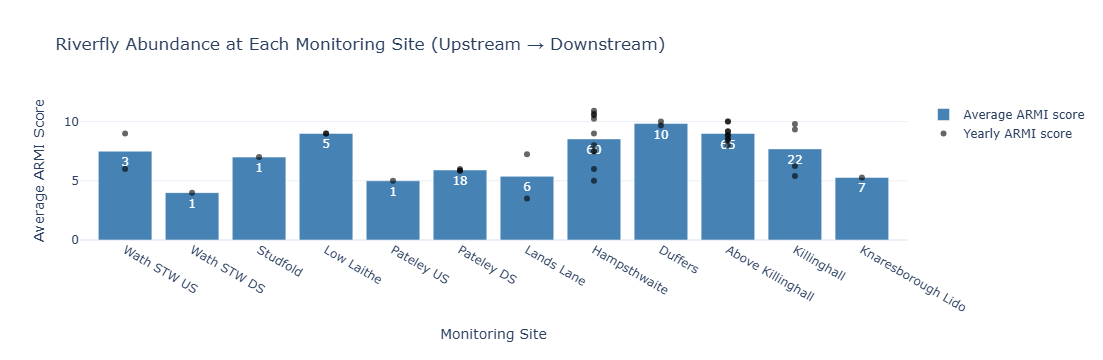

In [26]:
import pandas as pd
import plotly.graph_objects as go

# Copy & extract year
nidd = df_nidd.copy()
nidd['year'] = nidd['recorded_date'].dt.year

# Compute yearly and overall site ARMI
site_year_mean = (
    nidd.groupby(['site', 'year'])['armi_total']
        .mean()
        .reset_index(name='mean_armi')
)

site_summary = (
    site_year_mean.groupby('site')['mean_armi']
        .mean()
        .reset_index(name='site_mean_armi')
        .merge(
            nidd.groupby('site')['armi_total'].count().reset_index(name='total_surveys'),
            on='site'
        )
)

# Simplify site names
rename_map = {
    'Studfold Caravan Park - Howstean/Whit Beck': 'Studfold',
    'Pateley STW US': 'Pateley US',
    'Pateley STW DS': 'Pateley DS',
    'Above Killinghall Bridge': 'Above Killinghall',
    'Killinghall Bridge': 'Killinghall'
}

for df in [site_summary, site_year_mean]:
    df['site_simple'] = df['site'].replace(rename_map)

# Upstream → Downstream ordering
hydro_order = [
    'Wath US', 'Wath STW US', 'Wath STW DS', 'Studfold', 'Low Laithe',
    'Pateley US', 'Pateley DS', 'Lands Lane', 'Hampsthwaite',
    'Duffers', 'Above Killinghall', 'Killinghall', 'Knaresborough Lido'
]

for df in [site_summary, site_year_mean]:
    df['site_simple'] = pd.Categorical(df['site_simple'], categories=hydro_order, ordered=True)

site_summary = site_summary.sort_values('site_simple')

fig = go.Figure([
    # Bars for mean ARMI + survey count
    go.Bar(
        x=site_summary['site_simple'],
        y=site_summary['site_mean_armi'],
        marker_color='steelblue',
        name='Average ARMI score',
        text=site_summary['total_surveys'],
        hovertemplate="<b>%{x}</b><br>Average ARMI score: %{y:.1f}<br>Total surveys: %{text}<extra></extra>"
    ),
    # Dots for yearly ARMI
    go.Scatter(
        x=site_year_mean['site_simple'],
        y=site_year_mean['mean_armi'],
        mode='markers',
        marker=dict(color='black', size=6, opacity=0.6),
        name='Yearly ARMI score',
        customdata=site_year_mean['year'],
        hovertemplate="<b>%{x}</b><br>Year: %{customdata}<br>ARMI score: %{y:.1f}<extra></extra>"
    )
])

fig.update_layout(
    title='Riverfly Abundance at Each Monitoring Site (Upstream → Downstream)',
    xaxis_title='Monitoring Site',
    yaxis_title='Average ARMI Score',
    template='plotly_white',
    showlegend=True,
    margin=dict(b=120)
)

fig.show()

### QUESTION 2 Version 1

In [ ]:
# 2.2.2 Between-Site Abundance Adjusted for Survey Frequency

# Step 0: Ensure year column exists
nidd['year'] = nidd['recorded_date'].dt.year

# Step 1: Compute mean ARMI per site per year
site_year_mean = (
    nidd.groupby(['site', 'year'])['armi_total']
    .mean()
    .reset_index(name='mean_armi')
)

# Step 2: Compute overall site-level mean
site_mean = (
    site_year_mean.groupby('site')['mean_armi']
    .mean()
    .reset_index(name='site_mean_armi')
)

# Step 3: Count number of surveys per site
site_effort = (
    nidd.groupby('site')['armi_total']
    .count()
    .reset_index(name='n_surveys')
)

# Merge abundance and effort
site_summary = pd.merge(site_mean, site_effort, on='site')

# Step 4: Order sites upstream → downstream (based on known hydrology)
hydro_order = [
    'Wath STW US', 'Wath STW DS', 'Studfold Caravan Park - Howstean/Whit Beck',
    'Low Laithe', 'Pateley STW US', 'Pateley STW DS', 'Lands Lane',
    'Hampsthwaite', 'Duffers', 'Above Killinghall', 'Killinghall Bridge', 'Knaresborough Lido'
]

site_summary['site'] = pd.Categorical(site_summary['site'], categories=hydro_order, ordered=True)
site_summary = site_summary.sort_values('site')

# Step 5: Plot mean ARMI with survey effort annotation
fig = go.Figure()

fig.add_trace(go.Bar(
    x=site_summary['site'],
    y=site_summary['site_mean_armi'],
    marker_color='steelblue',
    name='Mean ARMI per Survey',
    hovertemplate=(
        "<b>Site:</b> %{x}<br>"
        "<b>Mean ARMI per Survey:</b> %{y:.2f}<br>"
        "<b>Number of Surveys:</b> %{text}<extra></extra>"
    ),
    text=site_summary['n_surveys']
))

fig.update_layout(
    title='Mean ARMI per Site (Adjusted for Survey Frequency)',
    xaxis_title='Monitoring Site (Upstream → Downstream)',
    yaxis_title='Mean ARMI per Survey',
    template='plotly_white',
    showlegend=False
)

fig.show()

In [ ]:
print(nidd.columns.tolist())

### QUESTION 2 Version 2

In [ ]:
nidd['year'] = nidd['recorded_date'].dt.year

site_year_mean = (
    nidd.groupby(['site', 'year'])['armi_total']
    .mean()
    .reset_index(name='mean_armi')
)

site_mean = (
    site_year_mean.groupby('site')['mean_armi']
    .mean()
    .reset_index(name='site_mean_armi')
)

site_effort = (
    nidd.groupby('site')['armi_total']
    .count()
    .reset_index(name='n_surveys')
)

site_summary = pd.merge(site_mean, site_effort, on='site')

# --- SIMPLIFY SITE NAMES FOR PLOTTING ---
rename_map = {
    'Studfold Caravan Park - Howstean/Whit Beck': 'Studfold',
    'Pateley STW US': 'Pateley US',
    'Pateley STW DS': 'Pateley DS',
    'Above Killinghall Bridge': 'Above Killinghall',
    'Killinghall Bridge': 'Killinghall'
}

site_summary['site_simple'] = site_summary['site'].replace(rename_map)
site_year_mean['site_simple'] = site_year_mean['site'].replace(rename_map)

# --- ORDER SITES UPSTREAM → DOWNSTREAM ---
hydro_order_simple = [
    'Wath STW US', 'Wath STW DS', 'Studfold', 'Low Laithe',
    'Pateley US', 'Pateley DS', 'Lands Lane', 'Hampsthwaite',
    'Duffers', 'Above Killinghall', 'Killinghall', 'Knaresborough Lido'
]

site_summary['site_simple'] = pd.Categorical(
    site_summary['site_simple'], categories=hydro_order_simple, ordered=True
)

site_year_mean['site_simple'] = pd.Categorical(
    site_year_mean['site_simple'], categories=hydro_order_simple, ordered=True
)

site_summary = site_summary.sort_values('site_simple')

# --- PLOT: BAR + DOTS + SURVEY EFFORT ---
fig = go.Figure()

# Bars (mean ARMI)
fig.add_trace(go.Bar(
    x=site_summary['site_simple'],
    y=site_summary['site_mean_armi'],
    marker_color='steelblue',
    opacity=0.7,
    name='Mean ARMI'
))

# Dots (site-year values)
fig.add_trace(go.Scatter(
    x=site_year_mean['site_simple'],
    y=site_year_mean['mean_armi'],
    mode='markers',
    marker=dict(color='black', size=6, opacity=0.6),
    name='Yearly ARMI'
))

# Add survey effort labels
fig.update_layout(
    annotations=[
        dict(
            x=row['site_simple'],
            y=-1,  # below x-axis
            text=f"n={row['n_surveys']}",
            showarrow=False,
            font=dict(size=10, color='gray')
        )
        for _, row in site_summary.iterrows()
    ]
)

fig.update_layout(
    title='Mean ARMI per Site (with Yearly Variation and Survey Effort)',
    xaxis_title='Monitoring Site (Upstream → Downstream)',
    yaxis_title='Mean ARMI per Survey',
    template='plotly_white',
    showlegend=True,
    margin=dict(b=80)
)

fig.show()

### QUESTION 2 BOX PLOT

This fragment creates a boxplot showing how **ARMI Total** varies between all River Nidd sites.  
The sites are manually ordered from **upstream to downstream**, allowing us to visually assess spatial patterns along the catchment.

This plot directly answers the question:  
**“How does the data vary between sites? (visually – can we order sites from the top of the catchment down)”**

Steps performed:
1. Filter the dataset to include only River Nidd sites.  
2. Define the correct upstream → downstream order.  
3. Convert the `Site` column into an ordered categorical variable.  
4. Produce a boxplot of ARMI Total for each site in river order.  
5. Add jittered points to show individual observations.

This visual allows us to compare:
- differences in ARMI levels between sites  
- downstream trends  
- variability at each site  
- potential anomalies (e.g., STW ownstream sites)  


In [ ]:
# 1. Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Filter dataset to only include River Nidd sites
#    Column name is lowercase: "river"
nidd_df = df[df["river"] == "Nidd"].copy()

# 3. Define upstream → downstream site order
site_order = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Low Laithe",
    "Pateley STW US",
    "Pateley STW DS",
    "Wath STW US",
    "Wath STW DS",
    "Hampsthwaite",
    "Duffers",
    "Above Killinghall",
    "Killinghall Bridge",
    "Knaresborough Lido",
    "Lands Lane"
]

# 4. Convert site column to an ordered categorical type
#    Column name is lowercase: "site"
nidd_df["site"] = pd.Categorical(nidd_df["site"], categories=site_order, ordered=True)

# 5. Create the boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=nidd_df,
    x="site",          # lowercase
    y="armi_total",    # lowercase
    order=site_order,
    color="lightblue"
)

# 6. Add jittered points to show individual samples
sns.stripplot(
    data=nidd_df,
    x="site",
    y="armi_total",
    order=site_order,
    color="black",
    alpha=0.5,
    size=3
)

# 7. Improve plot readability
plt.xticks(rotation=45, ha="right")
plt.title("ARMI Total Across River Nidd Sites (Upstream → Downstream)")
plt.xlabel("Site (Ordered Upstream → Downstream)")
plt.ylabel("ARMI Total")
plt.tight_layout()

# 8. Display the plot
plt.show()

### QUESTION 2 BAR CHART

This bar chart shows the **average ARMI Total** at each River Nidd site, ordered from upstream to downstream.  
It is a simple and intuitive visual for volunteers, allowing quick comparison of which sites tend to have higher or lower ARMI scores.

Unlike a boxplot, this chart does not show variability or outliers, but it is very easy to interpret and ideal for community communicaion.


In [ ]:
# 1. Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Filter to River Nidd
nidd_df = df[df["river"] == "Nidd"].copy()

# 3. Define upstream → downstream order
site_order = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Low Laithe",
    "Pateley STW US",
    "Pateley STW DS",
    "Wath STW US",
    "Wath STW DS",
    "Hampsthwaite",
    "Duffers",
    "Above Killinghall",
    "Killinghall Bridge",
    "Knaresborough Lido",
    "Lands Lane"
]

# 4. Compute mean ARMI per site
mean_df = (
    nidd_df.groupby("site")["armi_total"]
    .mean()
    .reindex(site_order)
    .reset_index()
)

# 5. Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(
    data=mean_df,
    x="site",
    y="armi_total",
    color="skyblue"
)

# 6. Improve readability
plt.xticks(rotation=45, ha="right")
plt.title("Mean ARMI Total per Site (Upstream → Downstream)")
plt.xlabel("Site")
plt.ylabel("Mean ARMI Total")
plt.tight_layout()

# 7. Show plot
plt.show()

### QUESTION 2 LINE CHART

This line chart shows how the **average ARMI Total** changes as you move downstream along the River Nidd.  
It is highly intuitive and ideal for storytelling, making it easy to spot increases, decreases, or sudden drops in river health.

This chart is simple to interpret and visually mirrors the flow of the rver.


In [ ]:
# 1. Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Filter to River Nidd
nidd_df = df[df["river"] == "Nidd"].copy()

# 3. Define upstream → downstream order
site_order = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Low Laithe",
    "Pateley STW US",
    "Pateley STW DS",
    "Wath STW US",
    "Wath STW DS",
    "Hampsthwaite",
    "Duffers",
    "Above Killinghall",
    "Killinghall Bridge",
    "Knaresborough Lido",
    "Lands Lane"
]

# 4. Compute mean ARMI per site
mean_df = (
    nidd_df.groupby("site")["armi_total"]
    .mean()
    .reindex(site_order)
    .reset_index()
)

# 5. Plot line chart
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=mean_df,
    x="site",
    y="armi_total",
    marker="o",
    linewidth=2,
    color="green"
)

# 6. Improve readability
plt.xticks(rotation=45, ha="right")
plt.title("Mean ARMI Total Along the River Nidd (Upstream → Downstream)")
plt.xlabel("Site")
plt.ylabel("Mean ARMI Total")
plt.tight_layout()

# 7. Show plot
plt.show()

### QUESTION 2 DOT PLOT

This dot plot shows **every individual ARMI Total measurement** at each River Nidd site.  
It is simple, transparent, and avoids statistical concepts like medians or quartiles.

Volunteers can easily see:
- how many samples were taken at each site  
- how spread out the values are  
- which sites tend to have higher or lower ARMI scores  


In [ ]:
# 1. Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Filter to River Nidd
nidd_df = df[df["river"] == "Nidd"].copy()

# 3. Define upstream → downstream order
site_order = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Low Laithe",
    "Pateley STW US",
    "Pateley STW DS",
    "Wath STW US",
    "Wath STW DS",
    "Hampsthwaite",
    "Duffers",
    "Above Killinghall",
    "Killinghall Bridge",
    "Knaresborough Lido",
    "Lands Lane"
]

# 4. Convert site to ordered category
nidd_df["site"] = pd.Categorical(nidd_df["site"], categories=site_order, ordered=True)

# 5. Plot dot plot
plt.figure(figsize=(14, 6))
sns.stripplot(
    data=nidd_df,
    x="site",
    y="armi_total",
    color="purple",
    alpha=0.6,
    size=5
)

# 6. Improve readability
plt.xticks(rotation=45, ha="right")
plt.title("ARMI Total per Sample Across River Nidd Sites")
plt.xlabel("Site (Upstream → Downstream)")
plt.ylabel("ARMI Total")
plt.tight_layout()

# 7. Show plot
plt.show()

### QUESTION 5 VERSION 1

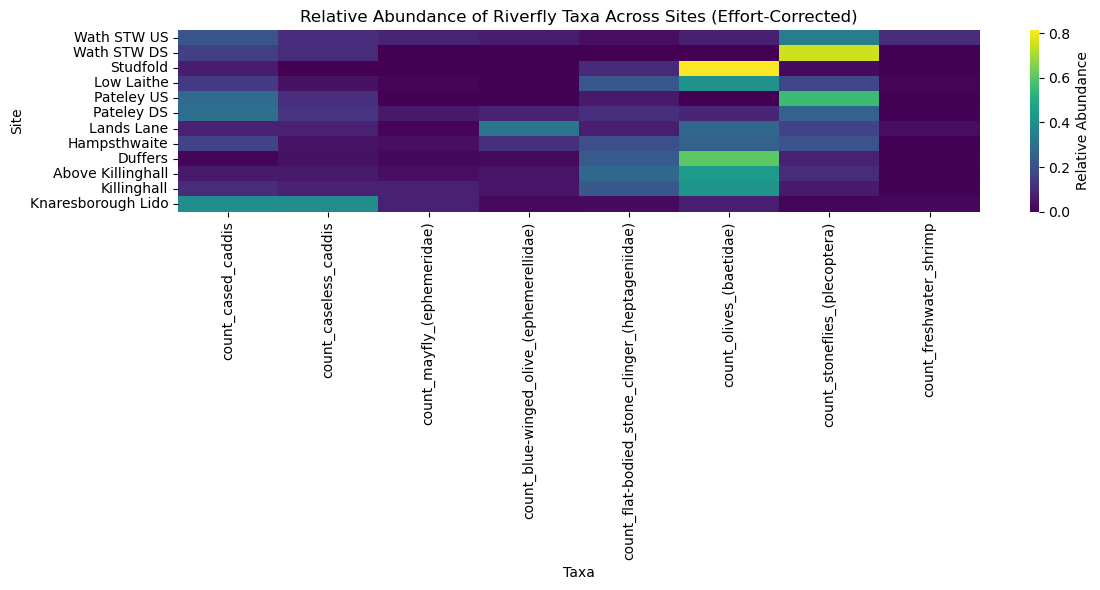

In [12]:
# 2.3.2 Visualising Species Differences Between Sites

# 1. Filter to River Nidd only
nidd_only = df[df['river'] == 'Nidd'].copy()

# 2. Drop rows with missing site names
nidd_only = nidd_only.dropna(subset=['site'])

# 3. Simplify site names for consistency
rename_map = {
    'Studfold Caravan Park - Howstean/Whit Beck': 'Studfold',
    'Pateley STW US': 'Pateley US',
    'Pateley STW DS': 'Pateley DS',
    'Above Killinghall Bridge': 'Above Killinghall',
    'Killinghall Bridge': 'Killinghall'
}
nidd_only['site'] = nidd_only['site'].replace(rename_map)

# 4. Define species count columns
species_cols = [
    'count_cased_caddis',
    'count_caseless_caddis',
    'count_mayfly_(ephemeridae)',
    'count_blue-winged_olive_(ephemerellidae)',
    'count_flat-bodied_stone_clinger_(heptageniidae)',
    'count_olives_(baetidae)',
    'count_stoneflies_(plecoptera)',
    'count_freshwater_shrimp'
]

# 5. Build species × site matrix (raw counts)
species_matrix = (
    nidd_only.groupby('site')[species_cols]
    .sum()
    .reset_index()
)

# 6. Convert raw counts to relative abundance (effort-corrected)
species_rel = species_matrix.copy()
species_rel[species_cols] = species_rel[species_cols].div(
    species_rel[species_cols].sum(axis=1), axis=0
)

# 7. Order sites upstream → downstream
hydro_order = [
    'Wath US', 'Wath STW US', 'Wath STW DS', 'Studfold', 'Low Laithe',
    'Pateley US', 'Pateley DS', 'Lands Lane', 'Hampsthwaite',
    'Duffers', 'Above Killinghall', 'Killinghall', 'Knaresborough Lido'
]

species_rel['site'] = pd.Categorical(species_rel['site'], categories=hydro_order, ordered=True)
species_rel = species_rel.sort_values('site').reset_index(drop=True)

# 8. Create heatmap of relative abundance
plt.figure(figsize=(12, 6))
sns.heatmap(
    species_rel.set_index('site')[species_cols],
    cmap='viridis',
    annot=False,
    cbar_kws={'label': 'Relative Abundance'}
)
plt.title('Relative Abundance of Riverfly Taxa Across Sites (Effort-Corrected)')
plt.xlabel('Taxa')
plt.ylabel('Site')
plt.tight_layout()
plt.show()

## QUESTION 5 HEATMAP

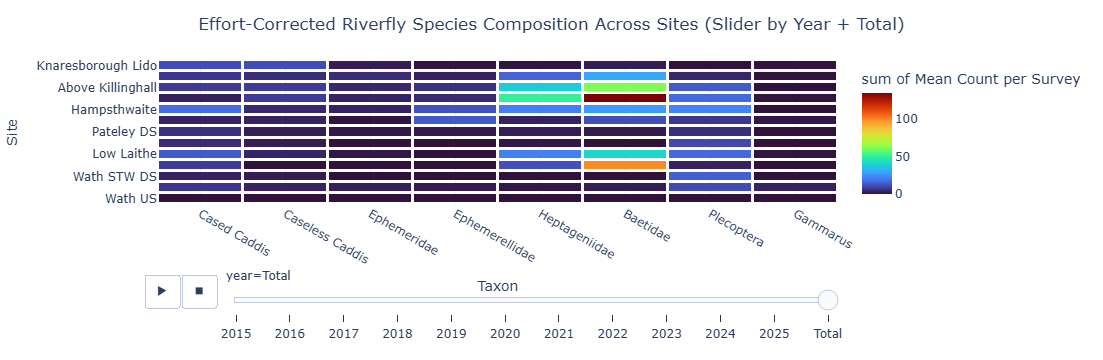

In [12]:
import pandas as pd
import numpy as np
import plotly.express as px

hydro_order_full = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Wath STW US",
    "Wath STW DS",
    "Pateley STW US",
    "Pateley STW DS",
    "Low Laithe",
    "Duffers",
    "Hampsthwaite",
    "Above Killinghall",
    "Killinghall Bridge",
    "Lands Lane",
    "Knaresborough Lido"
]

# --- Species columns ---
species_cols = [
    'count_cased_caddis', 'count_caseless_caddis',
    'count_mayfly_(ephemeridae)', 'count_blue-winged_olive_(ephemerellidae)',
    'count_flat-bodied_stone_clinger_(heptageniidae)',
    'count_olives_(baetidae)', 'count_stoneflies_(plecoptera)',
    'count_freshwater_shrimp'
]

# --- Add year column ---
df_nidd['year'] = df_nidd['recorded_date'].dt.year

# --- Compute mean counts per survey per site per year ---
species_per_year = (
    df_nidd.groupby(['site_simple', 'year'])[species_cols]
    .sum()
    .div(df_nidd.groupby(['site_simple', 'year']).size(), axis=0)
    .reset_index()
)

# --- Compute total across all years ---
species_total = (
    df_nidd.groupby('site_simple')[species_cols]
    .sum()
    .div(df_nidd.groupby('site_simple').size(), axis=0)
    .reset_index()
)
species_total['year'] = 'Total'

# --- Combine per-year and total ---
species_all = pd.concat([species_per_year, species_total], ignore_index=True)

# --- Rename taxa for readability ---
rename_taxa = {
    'count_cased_caddis': 'Cased Caddis',
    'count_caseless_caddis': 'Caseless Caddis',
    'count_mayfly_(ephemeridae)': 'Ephemeridae',
    'count_blue-winged_olive_(ephemerellidae)': 'Ephemerellidae',
    'count_flat-bodied_stone_clinger_(heptageniidae)': 'Heptageniidae',
    'count_olives_(baetidae)': 'Baetidae',
    'count_stoneflies_(plecoptera)': 'Plecoptera',
    'count_freshwater_shrimp': 'Gammarus'
}
species_all = species_all.rename(columns=rename_taxa)
species_cols_readable = list(rename_taxa.values())

# --- Define upstream → downstream site order ---
hydro_order = [
    'Wath US', 'Wath STW US', 'Wath STW DS', 'Studfold', 'Low Laithe',
    'Pateley US', 'Pateley DS', 'Lands Lane', 'Hampsthwaite',
    'Duffers', 'Above Killinghall', 'Killinghall', 'Knaresborough Lido'
]
species_all['site_simple'] = pd.Categorical(
    species_all['site_simple'], categories=hydro_order, ordered=True
)

# --- Melt to long format ---
species_long = species_all.melt(
    id_vars=['site_simple', 'year'],
    value_vars=species_cols_readable,
    var_name='Taxon',
    value_name='Mean Count per Survey'
)

# --- Create full site × year × taxon grid to fill missing ---
sites = species_long['site_simple'].cat.categories
years = [str(y) for y in range(2015, 2026)] + ['Total']
taxa = species_cols_readable

full_grid = pd.MultiIndex.from_product([sites, years, taxa], names=['site_simple', 'year', 'Taxon']).to_frame(index=False)

# Merge actual data, fill missing with 0
species_long['year'] = species_long['year'].astype(str)
species_long = pd.merge(full_grid, species_long, on=['site_simple', 'year', 'Taxon'], how='left')
species_long['Mean Count per Survey'] = species_long['Mean Count per Survey'].fillna(0)

# --- Set categorical orders for plotting ---
species_long['year'] = pd.Categorical(species_long['year'], categories=years, ordered=True)
species_long['site_simple'] = pd.Categorical(species_long['site_simple'], categories=hydro_order, ordered=True)
species_long['Taxon'] = pd.Categorical(species_long['Taxon'], categories=taxa, ordered=True)

# --- Create density heatmap with slider ---
fig = px.density_heatmap(
    species_long,
    x='Taxon',
    y='site_simple',
    z='Mean Count per Survey',
    animation_frame='year',
    color_continuous_scale='Turbo',
    text_auto=False,
    labels={'site_simple':'Site', 'Taxon':'Taxon', 'Mean Count per Survey':'Mean Count per Survey'}
)

fig.update_traces(
    xgap=3,
    ygap=3,
    hovertemplate="<b>Site:</b> %{y}<br><b>Taxon:</b> %{x}<br><b>Mean count per survey:</b> %{z:.2f}<extra></extra>"
)

fig.update_layout(
    title=dict(text="Effort-Corrected Riverfly Species Composition Across Sites", x=0.5),
    xaxis_title="Taxon",
    yaxis_title="Site",
    template="plotly_white",
    font=dict(size=12),
    height=50 * len(hydro_order),
    margin=dict(b=150)
)

fig.show()

### QUESTION 5 VERSION 2

In [ ]:
# ============================================================
# 2.3.2 Improved Heatmap (Colour-Blind Friendly + Readable Labels)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a copy of the relative abundance matrix
heatmap_df = species_rel.copy()

# 2. Rename taxa to short, readable labels
rename_taxa = {
    'count_cased_caddis': 'Cased Caddis',
    'count_caseless_caddis': 'Caseless Caddis',
    'count_mayfly_(ephemeridae)': 'Ephemeridae',
    'count_blue-winged_olive_(ephemerellidae)': 'Ephemerellidae',
    'count_flat-bodied_stone_clinger_(heptageniidae)': 'Heptageniidae',
    'count_olives_(baetidae)': 'Baetidae',
    'count_stoneflies_(plecoptera)': 'Plecoptera',
    'count_freshwater_shrimp': 'Gammarus'
}

heatmap_df = heatmap_df.rename(columns=rename_taxa)
short_cols = list(rename_taxa.values())

# 3. Determine the actual max value for better colour scaling
vmax_value = heatmap_df[short_cols].max().max()

# 4. Plot heatmap using a colour-blind-friendly palette (cividis)
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_df.set_index('site')[short_cols],
    cmap='cividis',          # colour-blind-friendly palette
    linewidths=0.5,          # thin gridlines for clarity
    linecolor='grey',
    vmin=0,
    vmax=vmax_value,
    cbar_kws={'label': 'Relative Abundance'}
)

plt.title('Relative Abundance of Riverfly Taxa Across Sites (Effort-Corrected)')
plt.xlabel('Taxa')
plt.ylabel('Site')
plt.tight_layout()
plt.show()


### Q5 Faceted Boxplots of ARMI Species Scores Across River Nidd Sites

This visual shows a separate boxplot for each riverfly species group, allowing us to compare how each species varies across sites from upstream to downstream.

This helps identify:
- which species are more abundant upstream vs downstream  
- which species show strong fluctuations  
- whether pollution‑sensitive groups (e.g., stoneflies, heptageniids) decline at certain sites  

This is a more analytical visual but still interpretable with uidance.


In [ ]:
# 1. Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Filter to River Nidd
nidd_df = df[df["river"] == "Nidd"].copy()

# 3. Define upstream → downstream order
site_order = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Low Laithe",
    "Pateley STW US",
    "Pateley STW DS",
    "Wath STW US",
    "Wath STW DS",
    "Hampsthwaite",
    "Duffers",
    "Above Killinghall",
    "Killinghall Bridge",
    "Knaresborough Lido",
    "Lands Lane"
]

# 4. Convert site to ordered category
nidd_df["site"] = pd.Categorical(nidd_df["site"], categories=site_order, ordered=True)

# 5. List of species columns
species_cols = [
    "armi_score_cased_caddis",
    "armi_score_caseless_caddis",
    "armi_score_mayfly_(ephemeridae)",
    "armi_score_blue-winged_olive_(ephemerellidae)",
    "armi_score_flat-bodied_stone_clinger_(heptageniidae)",
    "armi_score_olives_(baetidae)",
    "armi_score_stoneflies_(plecoptera)",
    "armi_score_freshwater_shrimp"
]

# 6. Melt into long format
long_df = nidd_df.melt(
    id_vars="site",
    value_vars=species_cols,
    var_name="species",
    value_name="score"
)

# 7. Plot faceted boxplots
g = sns.catplot(
    data=long_df,
    x="site",
    y="score",
    col="species",
    kind="box",
    col_wrap=4,
    height=4,
    sharey=False
)

# 8. Improve readability
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Q5 Heatmap of Mean ARMI Species Scores Across River Nidd Sites

This heatmap shows the average ARMI score for each species at each site.  
Darker colours indicate higher scores.

This is one of the most volunteer‑friendly ways to show species‑level patterns, making it easy to spot:
- species that decline downstream  
- species that spike at certain sites  
- changes in community compoition  


In [ ]:
# 1. Compute mean species scores per site
mean_species = (
    nidd_df.groupby("site")[species_cols]
    .mean()
    .reindex(site_order)
)

# 2. Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    mean_species.T,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt=".1f"
)

plt.title("Mean ARMI Species Scores Across River Nidd Sites")
plt.xlabel("Site (Upstream → Downstream)")
plt.ylabel("Species")
plt.tight_layout()
plt.show()

### Q5 Line Chart of ARMI Species Scores Along the River Nidd

This line chart shows how the average ARMI score for each species changes from upstream to downstream.

It is highly intuitive and ideal for storytelling, helping volunteers see:
- which species increase or decrease  
- where sensitive species drop  
- where tolerant species dominate  


In [ ]:
# 1. Compute mean species scores per site
mean_species = (
    nidd_df.groupby("site")[species_cols]
    .mean()
    .reindex(site_order)
    .reset_index()
)

# 2. Melt for plotting
long_mean = mean_species.melt(
    id_vars="site",
    value_vars=species_cols,
    var_name="species",
    value_name="score"
)

# 3. Plot line chart
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=long_mean,
    x="site",
    y="score",
    hue="species",
    marker="o"
)

plt.xticks(rotation=45, ha="right")
plt.title("Mean ARMI Species Scores Along the River Nidd")
plt.xlabel("Site (Upstream → Downstream)")
plt.ylabel("Mean ARMI Score")
plt.tight_layout()
plt.show()


### Q5 Stacked Bar Chart of ARMI Species Composition per Site

This stacked bar chart shows how the different riverfly species contribute to the total ARMI score at each site.

It is very intuitive for volunteers and highlights:
- changes in species composition  
- dominance of certain groups  
- loss of sensitive species downstream  


In [ ]:
# 1. Compute mean species scores per site
mean_species = (
    nidd_df.groupby("site")[species_cols]
    .mean()
    .reindex(site_order)
)

# 2. Plot stacked bar chart
plt.figure(figsize=(14, 6))
mean_species.plot(
    kind="bar",
    stacked=True,
    colormap="tab20",
    figsize=(14, 6)
)

plt.xticks(rotation=45, ha="right")
plt.title("Species Composition (Mean ARMI Scores) Across River Nidd Sites")
plt.xlabel("Site (Upstream → Downstream)")
plt.ylabel("Mean ARMI Score Contribution")
plt.tight_layout()
plt.show()


### Q6 Option A — Within‑Site Boxplots of ARMI Species Scores

This visual shows a separate boxplot for each species *within each site*, using all survey dates.  
It highlights how much each species fluctuates at a given site.

This helps identify:
- species that are stable vs highly variable  
- whether sensitive species (e.g., stoneflies, heptageniids) show occasional drops  
- whether tolerant species dominate consistently  
- whether a site shows signs of episodic pollution  

In [ ]:
# 1. Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Filter to River Nidd
nidd_df = df[df["river"] == "Nidd"].copy()

# 3. Define upstream → downstream order
site_order = [
    "Studfold Caravan Park - Howstean/Whit Beck",
    "Low Laithe",
    "Pateley STW US",
    "Pateley STW DS",
    "Wath STW US",
    "Wath STW DS",
    "Hampsthwaite",
    "Duffers",
    "Above Killinghall",
    "Killinghall Bridge",
    "Knaresborough Lido",
    "Lands Lane"
]

# 4. Convert site to ordered category
nidd_df["site"] = pd.Categorical(nidd_df["site"], categories=site_order, ordered=True)

# 5. Species columns
species_cols = [
    "armi_score_cased_caddis",
    "armi_score_caseless_caddis",
    "armi_score_mayfly_(ephemeridae)",
    "armi_score_blue-winged_olive_(ephemerellidae)",
    "armi_score_flat-bodied_stone_clinger_(heptageniidae)",
    "armi_score_olives_(baetidae)",
    "armi_score_stoneflies_(plecoptera)",
    "armi_score_freshwater_shrimp"
]

# 6. Melt into long format
long_df = nidd_df.melt(
    id_vars=["site", "recorded_date"],
    value_vars=species_cols,
    var_name="species",
    value_name="score"
)

# 7. Faceted boxplots (one site per panel)
g = sns.catplot(
    data=long_df,
    x="species",
    y="score",
    col="site",
    kind="box",
    col_wrap=3,
    height=4,
    sharey=False
)

# 8. Improve readability
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()

# 9. Export
g.savefig("Q6_nidd_faceted_boxplots.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import plotly.express as px

long_df["species_clean"] = long_df["species"].str.replace("armi_score_", "", regex=False)

fig = px.box(
    long_df,
    x="species_clean",
    y="score",
    facet_col="site",
    facet_col_wrap=3,
    points=False,  # turn off swarm points
    hover_data={
        "site": True,
        "species_clean": True,
        "score": True,
    }
)

# Make the boxes visually stronger
fig.update_traces(
    marker=dict(opacity=0),  # hide points
    line=dict(width=9),      # thicker box outline
    fillcolor="rgba(0,0,0,0.1)"  # subtle fill
)

fig.update_layout(
    height=1200,
    width=1200,
    showlegend=False,
    title="Interactive ARMI Species Boxplots – River Nidd"
)

fig.update_xaxes(tickangle=90)

fig.show()


### Q6 Option B — Heatmap of ARMI Species Scores Over Time (Within Each Site)

This heatmap shows how each species' ARMI score changes over time at a given site.  
Each row is a species, each column is a survey date.

This helps volunteers see:
- which species fluctuate over time  
- whether sensitive species drop at certain dates  
- whether tolerant species dominate consistently  
- whether the site shows episodic pollution events  


### Q6 Option C — Line Charts of ARMI Species Scores Over Time (Within Each Site)

This visual shows how each species' ARMI score changes over time at each site.  
Each line represents a species.

This helps identify:
- sudden drops in sensitive species  
- long‑term trends  
- species that fluctuate strongly  
- stable vs unstable sites  


In [ ]:
# 1. Loop through each site and plot species over time
for site in site_order:
    site_df = nidd_df[nidd_df["site"] == site].copy()
    
    if site_df.empty:
        continue
    
    # 2. Melt for plotting
    long_site = site_df.melt(
        id_vars="recorded_date",
        value_vars=species_cols,
        var_name="species",
        value_name="score"
    )
    
    # 3. Plot line chart
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=long_site,
        x="recorded_date",
        y="score",
        hue="species",
        marker="o"
    )
    
    plt.title(f"Species ARMI Scores Over Time — {site}")
    plt.xlabel("Date")
    plt.ylabel("ARMI Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

# Create a single multi-page PDF
with PdfPages("Q6_nidd_species_timeseries_all_sites.pdf") as pdf:
    
    # 1. Loop through each site and plot species over time
    for site in site_order:
        site_df = nidd_df[nidd_df["site"] == site].copy()
        
        if site_df.empty:
            continue
        
        # 2. Melt for plotting
        long_site = site_df.melt(
            id_vars="recorded_date",
            value_vars=species_cols,
            var_name="species",
            value_name="score"
        )
        
        # 3. Plot line chart
        plt.figure(figsize=(12, 6))
        sns.lineplot(
            data=long_site,
            x="recorded_date",
            y="score",
            hue="species",
            marker="o"
        )
        
        plt.title(f"Species ARMI Scores Over Time — {site}")
        plt.xlabel("Date")
        plt.ylabel("ARMI Score")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        
        # 4. Save this figure as a page in the PDF
        pdf.savefig()
        plt.close()   # prevents figures stacking up in memory


### Q6 Option D — Stacked Bar Chart of Species Composition Over Time (Within Each Site)

This stacked bar chart shows how the different species contribute to the total ARMI score at each site over time.

This helps volunteers see:
- shifts in species composition  
- dominance of tolerant species  
- loss of sensitive species  
- changes that may indicate pollution events  


In [ ]:
# 1. Loop through each site and create stacked bars
for site in site_order:
    site_df = nidd_df[nidd_df["site"] == site].copy()
    
    if site_df.empty:
        continue
    
    # 2. Compute mean species scores per date
    comp_df = site_df.groupby("recorded_date")[species_cols].mean()
    
    # 3. Plot stacked bar chart
    plt.figure(figsize=(12, 6))
    comp_df.plot(
        kind="bar",
        stacked=True,
        colormap="tab20",
        figsize=(12, 6)
    )
    
    plt.title(f"Species Composition Over Time — {site}")
    plt.xlabel("Date")
    plt.ylabel("ARMI Score Contribution")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

# Create a single multi-page PDF
with PdfPages("Q6_nidd_stackedbars_all_sites.pdf") as pdf:
    
    # 1. Loop through each site and create stacked bars
    for site in site_order:
        site_df = nidd_df[nidd_df["site"] == site].copy()
        
        if site_df.empty:
            continue
        
        # 2. Compute mean species scores per date
        comp_df = site_df.groupby("recorded_date")[species_cols].mean()
        
        # 3. Plot stacked bar chart
        plt.figure(figsize=(12, 6))
        comp_df.plot(
            kind="bar",
            stacked=True,
            colormap="tab20",
            figsize=(12, 6)
        )
        
        plt.title(f"Species Composition Over Time — {site}")
        plt.xlabel("Date")
        plt.ylabel("ARMI Score Contribution")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        
        # 4. Save this figure as a page in the PDF
        pdf.savefig()
        plt.close()


In [ ]:
# 1. Loop through each site and create a heatmap
for site in site_order:
    site_df = nidd_df[nidd_df["site"] == site].copy()
    
    if site_df.empty:
        continue  # skip sites with no data
    
    # 2. Melt species columns into long format
    long_df = site_df.melt(
        id_vars=["recorded_date"],
        value_vars=species_cols,
        var_name="species",
        value_name="score"
    )
    
    # 3. Pivot to species × date
    pivot_df = long_df.pivot_table(
        index="species",
        columns="recorded_date",
        values="score",
        aggfunc="mean"
    )
    
    # 4. Plot heatmap
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        pivot_df,
        cmap="YlGnBu",
        linewidths=0.5
    )
    
    plt.title(f"Species ARMI Scores Over Time — {site}")
    plt.xlabel("Date")
    plt.ylabel("Species")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # 5. Export
    plt.savefig("Q6_nidd_heatmaps.pdf", bbox_inches="tight")
    plt.show()


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("Q6_nidd_heatmaps_all_sites.pdf") as pdf:
    for site in site_order:
        site_df = nidd_df[nidd_df["site"] == site].copy()
        if site_df.empty:
            continue

        long_df = site_df.melt(
            id_vars=["recorded_date"],
            value_vars=species_cols,
            var_name="species",
            value_name="score"
        )

        pivot_df = long_df.pivot_table(
            index="species",
            columns="recorded_date",
            values="score",
            aggfunc="mean"
        )

        plt.figure(figsize=(12, 6))
        sns.heatmap(pivot_df, cmap="YlGnBu", linewidths=0.5)

        plt.title(f"Species ARMI Scores Over Time — {site}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()

        pdf.savefig()   # saves this page
        plt.close()


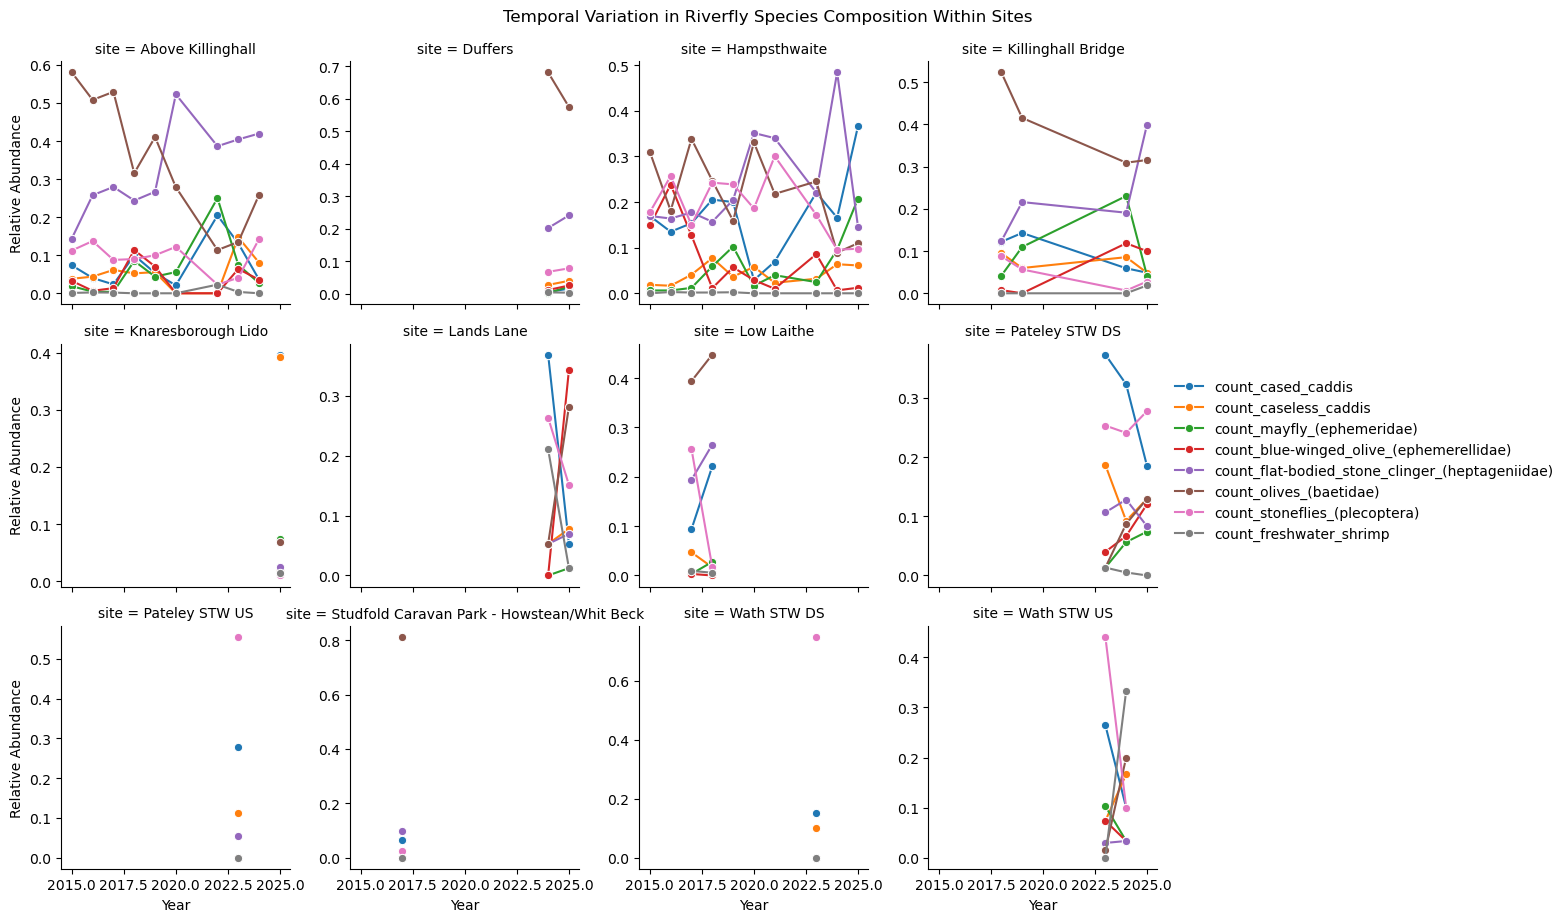

In [14]:
# 2.4.1 Within-Site Time Series

import pandas as pd

# --- Make sure your main dataframe exists ---
# Replace `df` with your actual dataframe name if different
# Filter to River Nidd
nidd_only = df[df['river'].str.lower() == 'nidd'].copy()

# Drop rows with missing site or date
nidd_only = nidd_only.dropna(subset=['site', 'recorded_date'])

# Create a 'year' column
nidd_only['year'] = pd.to_datetime(nidd_only['recorded_date']).dt.year

# 0. Ensure year column exists
nidd_only['year'] = pd.to_datetime(nidd_only['recorded_date']).dt.year

# 1. Aggregate by site × year
site_year = (
    nidd_only.groupby(['site', 'year'])[species_cols]
    .sum()
    .reset_index()
)

# 2. Compute relative abundance per site-year
site_year_rel = site_year.copy()
site_year_rel[species_cols] = site_year_rel[species_cols].div(
    site_year_rel[species_cols].sum(axis=1), axis=0
)

# 3. Convert to long format for plotting
plot_long = site_year_rel.melt(
    id_vars=['site', 'year'],
    value_vars=species_cols,
    var_name='taxon',
    value_name='relative_abundance'
)

# 4. Clean taxon names for readability (if you have a rename map)
# plot_long['taxon'] = plot_long['taxon'].replace(rename_taxa)

# 5. Faceted line plot (one panel per site)
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    plot_long,
    col="site",
    col_wrap=4,
    height=3,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="year",
    y="relative_abundance",
    hue="taxon",
    marker="o"
)

g.add_legend()
g.set_axis_labels("Year", "Relative Abundance")
g.fig.suptitle("Temporal Variation in Riverfly Species Composition Within Sites", y=1.02)

plt.show()